In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os, time, json, joblib
warnings.filterwarnings('ignore')
%matplotlib inline
pd.set_option('display.float_format', lambda x: '%.3f' % x)

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_auc_score,
    roc_curve, auc)


#   UNSUPERVISED LEARNING MODELS
from sklearn.ensemble import IsolationForest   
from sklearn.cluster  import KMeans           
from sklearn.decomposition import PCA          

# ══════════════════════════════════════════════════════════
#    SUPERVISED LEARNING MODELS
# ══════════════════════════════════════════════════════════
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm      import SVC
from sklearn.linear_model import LogisticRegression   
from xgboost import XGBClassifier


In [2]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Column names 
COL_NAMES = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','attack','level'
]

#  Full attack-type → category mapping (37 attack types) 
ATTACK_MAP = {
    'normal':'Normal',
    # DoS — overwhelm/crash the target
    'neptune':'DoS','back':'DoS','land':'DoS','pod':'DoS','smurf':'DoS',
    'teardrop':'DoS','mailbomb':'DoS','apache2':'DoS','processtable':'DoS',
    # Probe — scan network for vulnerabilities
    'ipsweep':'Probe','nmap':'Probe','portsweep':'Probe','satan':'Probe',
    'mscan':'Probe','saint':'Probe',
    # R2L — unauthorised access from remote machine
    'ftp_write':'R2L','guess_passwd':'R2L','imap':'R2L','multihop':'R2L',
    'phf':'R2L','spy':'R2L','warezclient':'R2L','warezmaster':'R2L',
    'sendmail':'R2L','named':'R2L','snmpgetattack':'R2L','snmpguess':'R2L',
    'worm':'R2L','xlock':'R2L','xsnoop':'R2L','httptunnel':'R2L',
    # U2R — escalate privileges to root/admin
    'buffer_overflow':'U2R','loadmodule':'U2R','perl':'U2R','rootkit':'U2R',
    'ps':'U2R','sqlattack':'U2R','xterm':'U2R'
}



# REAL NSL-KDD DATA FILES
train_df = pd.read_csv('KDDTrain+.txt.zip', names=COL_NAMES)
test_df  = pd.read_csv('KDDTest+.txt.zip',  names=COL_NAMES)

# Map to 5 categories
train_df['attack_category'] = train_df['attack'].map(ATTACK_MAP).fillna('R2L')
test_df['attack_category']  = test_df['attack'].map(ATTACK_MAP).fillna('R2L')

# Basic dataset info
print(f"Training set : {train_df.shape[0]:,} records × {train_df.shape[1]} columns")
print(f"Test set     : {test_df.shape[0]:,} records × {test_df.shape[1]} columns")
print(f"Attack types : {train_df['attack'].nunique()} unique → mapped to 5 categories")
print()

# Clean category distribution (NO bars)
print("Category distribution (Training):")
vc = train_df['attack_category'].value_counts()

for cat, n in vc.items():
    percentage = (n / len(train_df)) * 100
    print(f"{cat:<10} {n:>10,}   ({percentage:6.2f}%)")

print()

# Preview selected columns
print(train_df[['duration','protocol_type','service','flag',  'src_bytes','dst_bytes','attack','attack_category']].head(5))

Training set : 125,973 records × 44 columns
Test set     : 22,544 records × 44 columns
Attack types : 23 unique → mapped to 5 categories

Category distribution (Training):
Normal         67,343   ( 53.46%)
DoS            45,927   ( 36.46%)
Probe          11,656   (  9.25%)
R2L               995   (  0.79%)
U2R                52   (  0.04%)

   duration protocol_type   service flag  src_bytes  dst_bytes   attack  \
0         0           tcp  ftp_data   SF        491          0   normal   
1         0           udp     other   SF        146          0   normal   
2         0           tcp   private   S0          0          0  neptune   
3         0           tcp      http   SF        232       8153   normal   
4         0           tcp      http   SF        199        420   normal   

  attack_category  
0          Normal  
1          Normal  
2             DoS  
3          Normal  
4          Normal  


---
# Data Cleaning

In [4]:
print("=" * 50)
print("  DATA QUALITY CHECK")
print("=" * 50)

# Null values
nulls = train_df.isnull().sum().sum()
print(f"\nNull values     : {nulls}  {' None' if nulls==0 else ' Found!'}")

# Duplicates
dups = train_df.duplicated().sum()
print(f"Duplicate rows  : {dups}  {' None' if dups==0 else ' Found — dropping...'}")
if dups > 0:
    train_df.drop_duplicates(inplace=True)
    print(f"  After drop: {len(train_df):,} rows remain")

# Data types
print(f"\nData types:")
print(f"  Numeric   : {train_df.select_dtypes(include=np.number).shape[1]} columns")
print(f"  Categorical: {train_df.select_dtypes(include='object').shape[1]} columns")

# Categorical value counts
print("\nCategorical feature unique values:")
for col in ['protocol_type','service','flag']:
    print(f"  {col:<15}: {train_df[col].nunique()} unique values")
    if train_df[col].nunique() <= 5:
        print(f"               {list(train_df[col].unique())}")



  DATA QUALITY CHECK

Null values     : 0   None
Duplicate rows  : 0   None

Data types:
  Numeric   : 39 columns
  Categorical: 5 columns

Categorical feature unique values:
  protocol_type  : 3 unique values
               ['tcp', 'udp', 'icmp']
  service        : 70 unique values
  flag           : 11 unique values


---
# Exploratory Data Analysis (EDA)

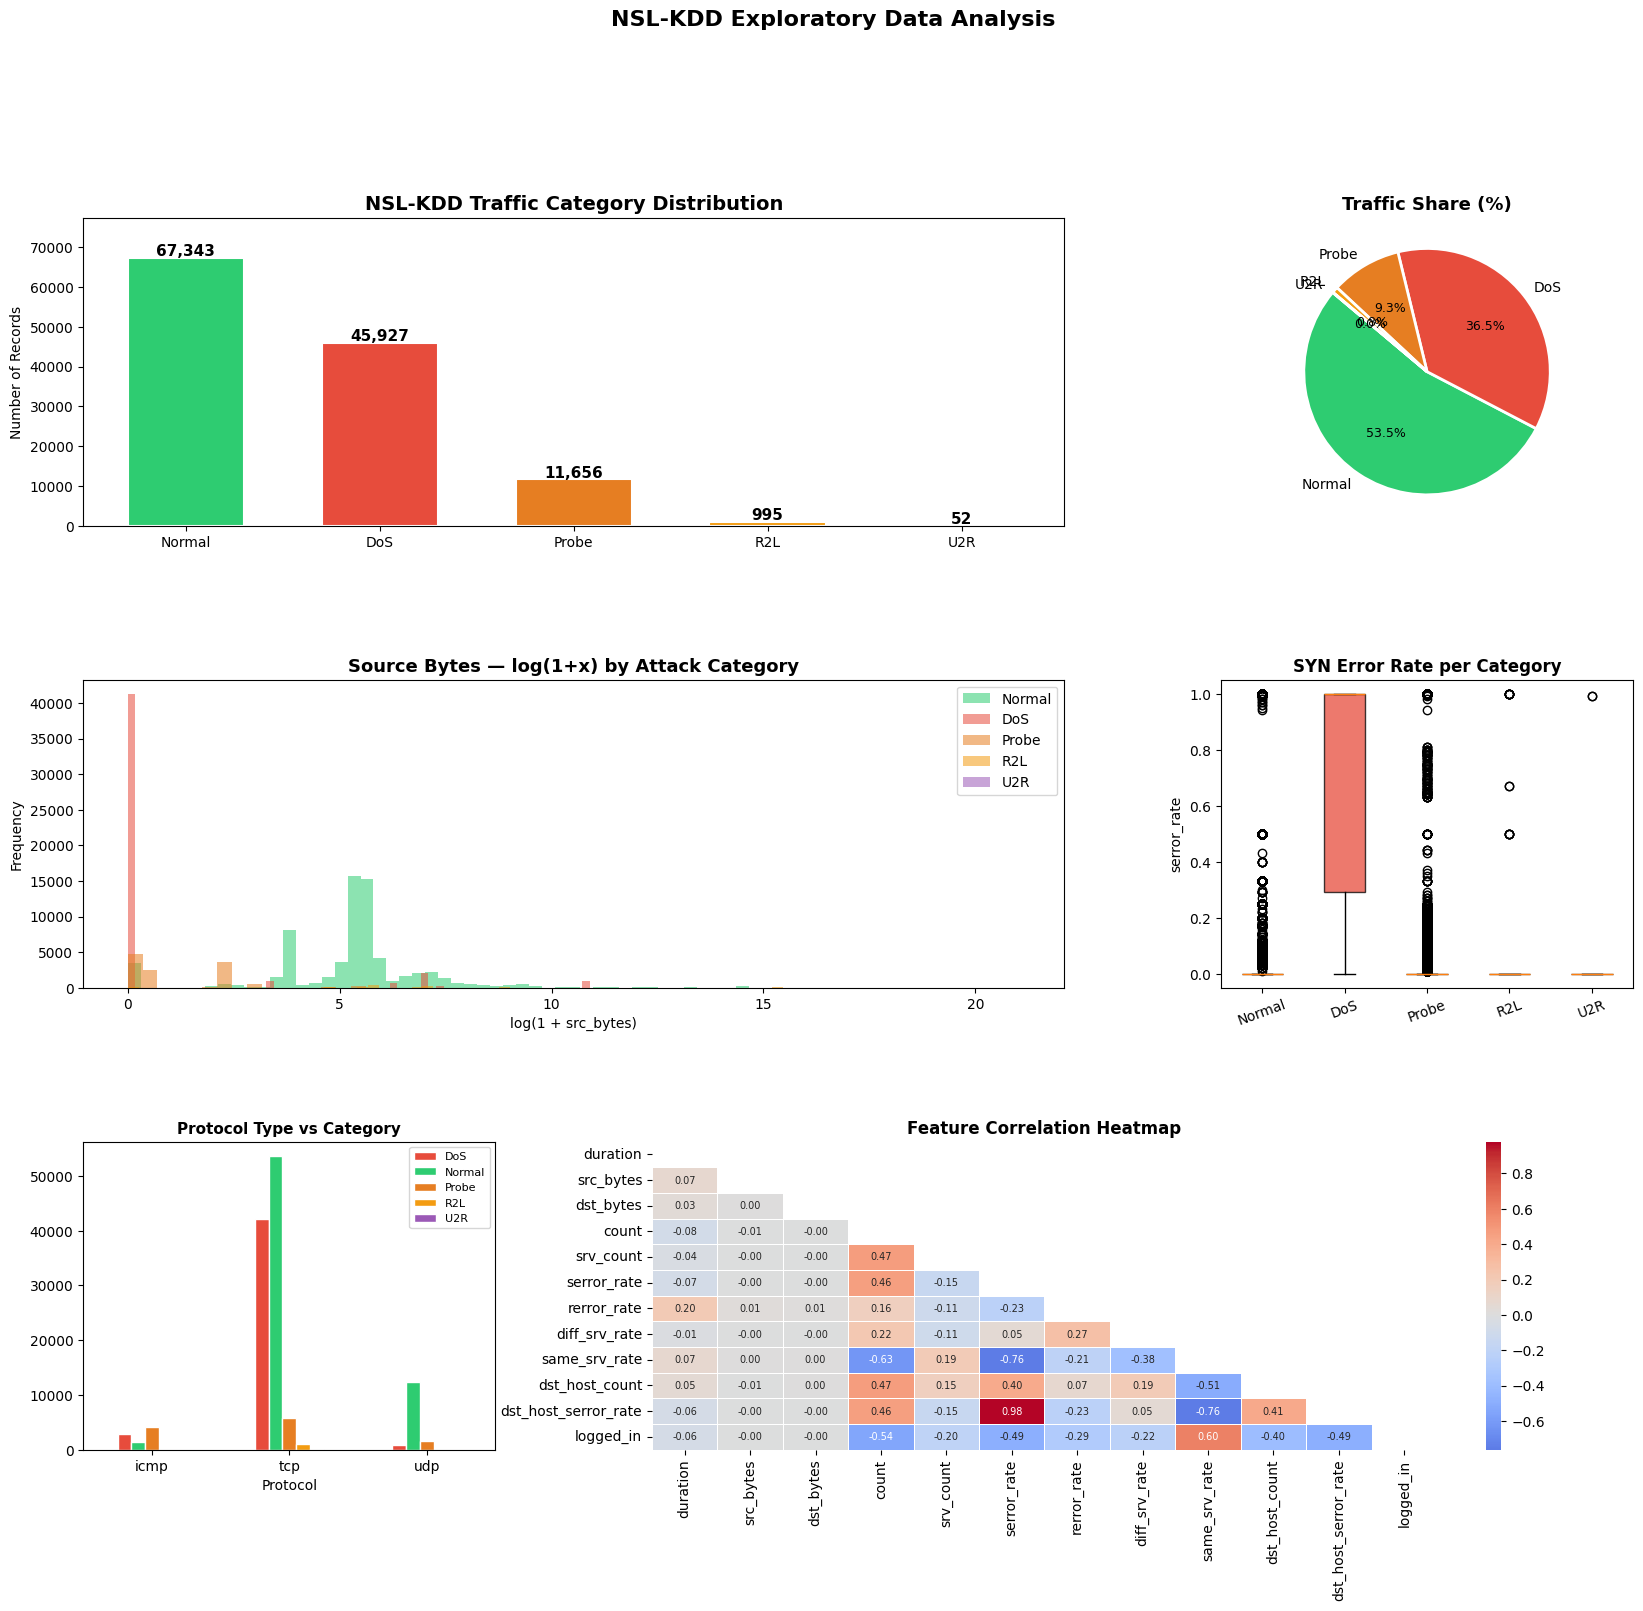

In [5]:

CAT_COLORS  = {'Normal':'#2ecc71','DoS':'#e74c3c','Probe':'#e67e22','R2L':'#f39c12','U2R':'#9b59b6'}
RISK_COLORS = {'Low':'#27ae60','Medium':'#f39c12','High':'#c0392b'}
PALETTE     = CAT_COLORS
SEVERITY    = {'Normal':0,'Probe':30,'DoS':70,'R2L':85,'U2R':100,'Unknown (Zero-Day)':55}

#   Distribution Overview 
fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, hspace=0.50, wspace=0.38)
vc = train_df['attack_category'].value_counts()
colors = [CAT_COLORS[c] for c in vc.index]

# 1. Bar chart
ax1 = fig.add_subplot(gs[0, :2])
bars = ax1.bar(vc.index, vc.values, color=colors, edgecolor='white', linewidth=1.5, width=0.6)
for bar, v in zip(bars, vc.values):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
             f'{v:,}', ha='center', fontsize=11, fontweight='bold')
ax1.set_title('NSL-KDD Traffic Category Distribution', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Records')
ax1.set_ylim(0, vc.max()*1.15)

# 2. Pie chart
ax2 = fig.add_subplot(gs[0, 2])
wedges, texts, autos = ax2.pie(vc.values, labels=vc.index, colors=colors,
    autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor':'white','linewidth':2})
for t in autos: t.set_fontsize(9)
ax2.set_title('Traffic Share (%)', fontsize=13, fontweight='bold')

# 3. src_bytes distribution
ax3 = fig.add_subplot(gs[1, :2])
for cat, col in CAT_COLORS.items():
    sub = train_df[train_df['attack_category']==cat]['src_bytes']
    if len(sub): ax3.hist(np.log1p(sub), bins=60, alpha=0.55, label=cat, color=col)
ax3.set_title('Source Bytes — log(1+x) by Attack Category', fontsize=13, fontweight='bold')
ax3.set_xlabel('log(1 + src_bytes)')
ax3.set_ylabel('Frequency')
ax3.legend(fontsize=10)

# 4. SYN error rate boxplot
ax4 = fig.add_subplot(gs[1, 2])
data_box = [train_df[train_df['attack_category']==c]['serror_rate'].values for c in vc.index]
bp = ax4.boxplot(data_box, patch_artist=True, labels=vc.index)
for patch, col in zip(bp['boxes'], colors):
    patch.set_facecolor(col); patch.set_alpha(0.75)
ax4.set_title('SYN Error Rate per Category', fontsize=12, fontweight='bold')
ax4.set_ylabel('serror_rate')
ax4.tick_params(axis='x', rotation=20)

# 5. Protocol type
ax5 = fig.add_subplot(gs[2, 0])
pt = train_df.groupby(['protocol_type','attack_category']).size().unstack(fill_value=0)
pt.plot(kind='bar', ax=ax5, color=[CAT_COLORS.get(c,'grey') for c in pt.columns], edgecolor='white')
ax5.set_title('Protocol Type vs Category', fontsize=11, fontweight='bold')
ax5.set_xlabel('Protocol')
ax5.legend(fontsize=8); ax5.tick_params(axis='x', rotation=0)

# 6. Correlation heatmap
ax6 = fig.add_subplot(gs[2, 1:])
num_feats = ['duration','src_bytes','dst_bytes','count','srv_count',
             'serror_rate','rerror_rate','diff_srv_rate','same_srv_rate',
             'dst_host_count','dst_host_serror_rate','logged_in']
corr = train_df[num_feats].corr()
sns.heatmap(corr, mask=np.triu(np.ones_like(corr,bool)), ax=ax6,
            cmap='coolwarm', center=0, annot=True, fmt='.2f',
            annot_kws={'size':7}, linewidths=0.5)
ax6.set_title('Feature Correlation Heatmap', fontsize=12, fontweight='bold')
plt.suptitle('NSL-KDD Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=130, bbox_inches='tight')
plt.show()

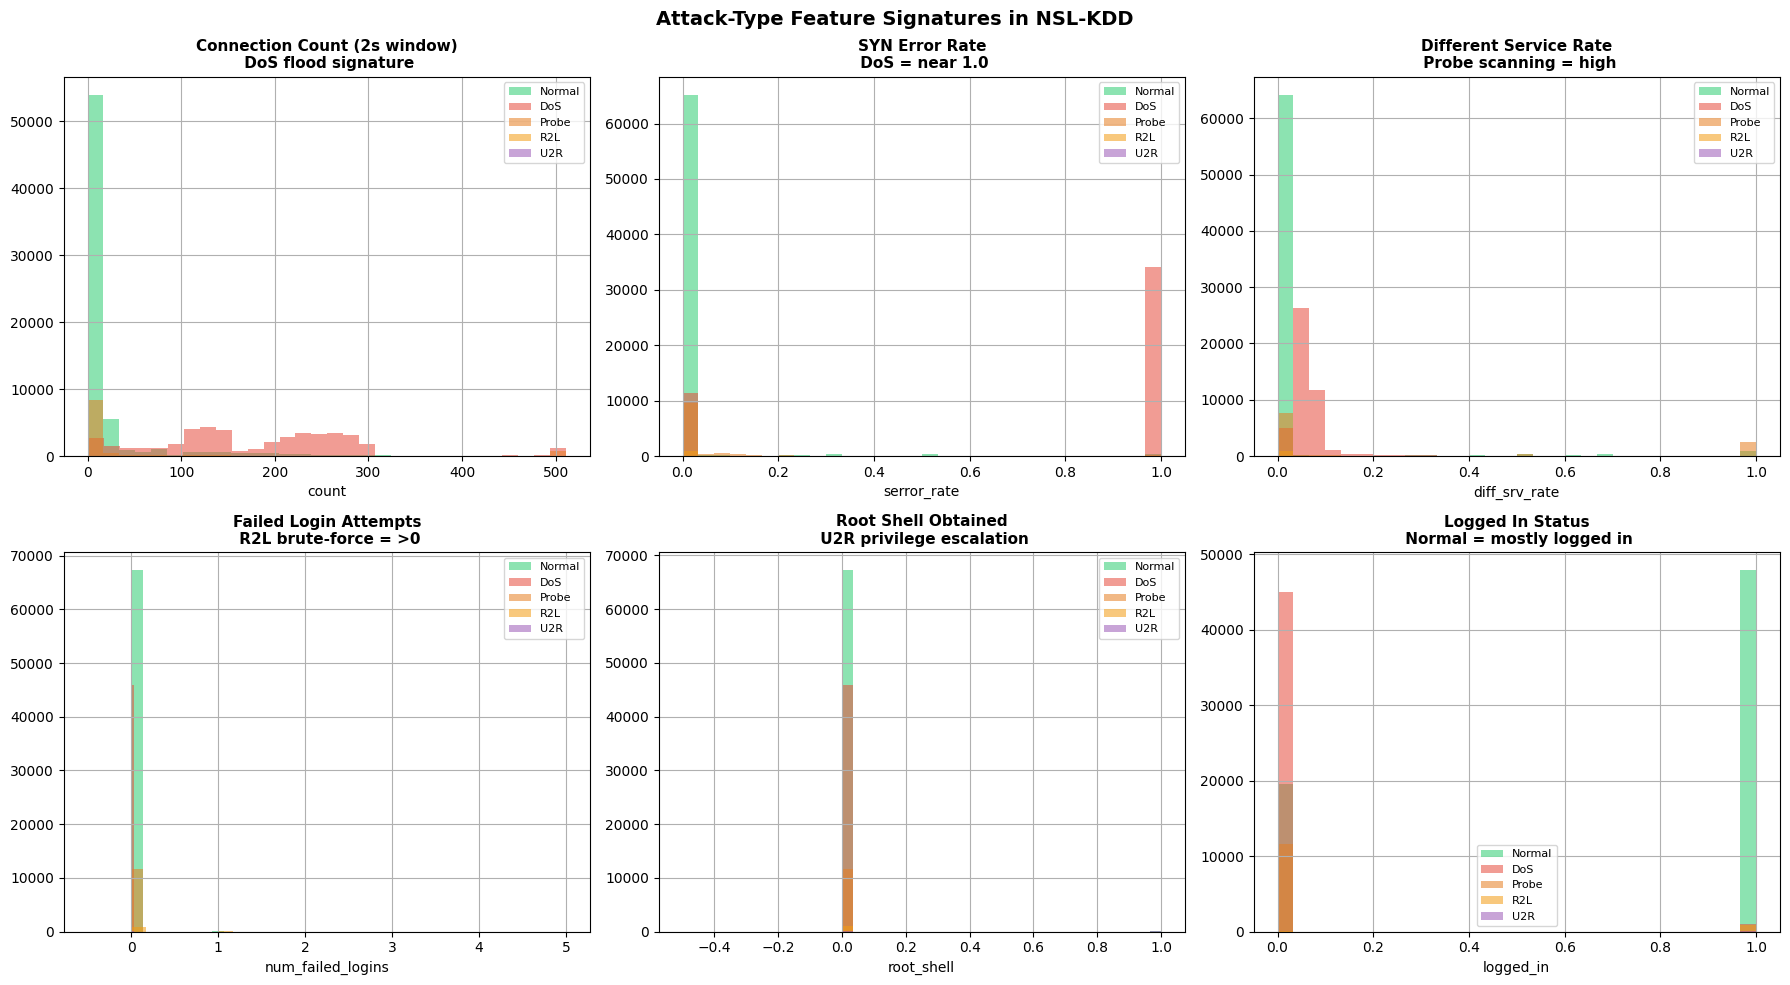

In [6]:
#  Attack-Specific Feature Signatures 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

sig_features = [
    ('count',            'Connection Count (2s window)', 'DoS flood signature'),
    ('serror_rate',      'SYN Error Rate',               'DoS = near 1.0'),
    ('diff_srv_rate',    'Different Service Rate',        'Probe scanning = high'),
    ('num_failed_logins','Failed Login Attempts',         'R2L brute-force = >0'),
    ('root_shell',       'Root Shell Obtained',           'U2R privilege escalation'),
    ('logged_in',        'Logged In Status',              'Normal = mostly logged in'),
]

for ax, (feat, title, note) in zip(axes, sig_features):
    for cat in ['Normal','DoS','Probe','R2L','U2R']:
        sub = train_df[train_df['attack_category']==cat][feat]
        sub.hist(bins=30, alpha=0.55, label=cat,
                 color=CAT_COLORS.get(cat,'grey'), ax=ax)
    ax.set_title(f'{title}\n {note}', fontsize=11, fontweight='bold')
    ax.set_xlabel(feat); ax.legend(fontsize=8)

plt.suptitle('Attack-Type Feature Signatures in NSL-KDD', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_signatures.png', dpi=130, bbox_inches='tight')
plt.show()


---
#  Preprocessing

In [7]:
print(" Label Encoding for categorical features")
print("-" * 50)
CAT_COLS = ['protocol_type','service','flag']

encoders = {}
train_enc = train_df.copy()
test_enc  = test_df.copy()

for col in CAT_COLS:
    le = LabelEncoder()
    combined = pd.concat([train_df[col], test_df[col]]).astype(str)
    le.fit(combined)
    train_enc[col] = le.transform(train_df[col].astype(str))
    test_enc[col]  = le.transform(test_df[col].astype(str))
    encoders[col]  = le
    print(f"  {col:<15} → {len(le.classes_)} categories encoded")

print()
print(" Creating binary and multi-class labels")
print("-" * 50)
train_enc['binary_label'] = (train_enc['attack_category'] != 'Normal').astype(int)
test_enc['binary_label']  = (test_enc['attack_category']  != 'Normal').astype(int)
print(f"  Binary  : 0=Normal, 1=Attack")
print(f"  Normal  : {(train_enc.binary_label==0).sum():,}")
print(f"  Attack  : {(train_enc.binary_label==1).sum():,}")

print()
print(" Feature / Target Split")
print("-" * 50)
DROP = ['attack','attack_category','binary_label','level']
FEAT_COLS = [c for c in train_enc.columns if c not in DROP]

X_all    = train_enc[FEAT_COLS].values
y_multi  = train_enc['attack_category'].values
y_bin    = train_enc['binary_label'].values
X_test_r = test_enc[FEAT_COLS].values
y_test_m = test_enc['attack_category'].values
y_test_b = test_enc['binary_label'].values
print(f"  Features : {len(FEAT_COLS)}")
print(f"  Train    : {X_all.shape}")
print(f"  Test     : {X_test_r.shape}")

print()
print("Standard Scaling")
print("-" * 50)
scaler     = StandardScaler()
X_scaled   = scaler.fit_transform(X_all)
X_test_sc  = scaler.transform(X_test_r)
print("  StandardScaler applied (mean=0, std=1)  ")

print()
print("Train / Validation Split  (80% / 20%, stratified)")
print("-" * 50)
X_tr, X_val, y_tr_m, y_val_m, y_tr_b, y_val_b = train_test_split(
    X_scaled, y_multi, y_bin,
    test_size=0.20, random_state=42, stratify=y_bin
)
print(f"  Training   : {X_tr.shape[0]:,}")
print(f"  Validation : {X_val.shape[0]:,}")
print()


 Label Encoding for categorical features
--------------------------------------------------


  protocol_type   → 3 categories encoded
  service         → 70 categories encoded
  flag            → 11 categories encoded

 Creating binary and multi-class labels
--------------------------------------------------
  Binary  : 0=Normal, 1=Attack
  Normal  : 67,343
  Attack  : 58,630

 Feature / Target Split
--------------------------------------------------
  Features : 41
  Train    : (125973, 41)
  Test     : (22544, 41)

Standard Scaling
--------------------------------------------------
  StandardScaler applied (mean=0, std=1)  

Train / Validation Split  (80% / 20%, stratified)
--------------------------------------------------
  Training   : 100,778
  Validation : 25,195



---
# Feature Engineering & Selection

Computing Mutual Information scores against binary label...
Top 20 features selected from 41 total.



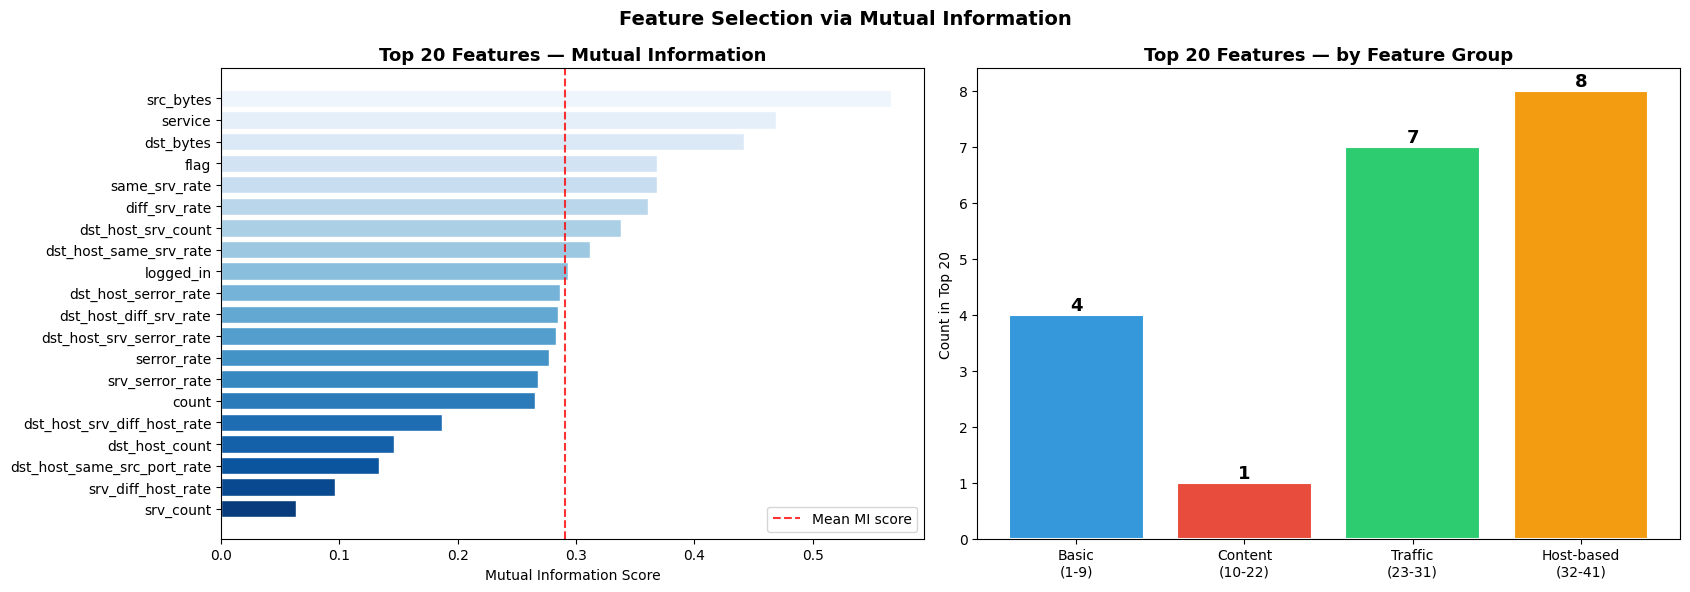

Top 20 selected features:
   1. src_bytes                            MI = 0.56581
   2. service                              MI = 0.46884
   3. dst_bytes                            MI = 0.44213
   4. flag                                 MI = 0.36819
   5. same_srv_rate                        MI = 0.36815
   6. diff_srv_rate                        MI = 0.36062
   7. dst_host_srv_count                   MI = 0.33765
   8. dst_host_same_srv_rate               MI = 0.31214
   9. logged_in                            MI = 0.29304
  10. dst_host_serror_rate                 MI = 0.28677
  11. dst_host_diff_srv_rate               MI = 0.28505
  12. dst_host_srv_serror_rate             MI = 0.28338
  13. serror_rate                          MI = 0.27727
  14. srv_serror_rate                      MI = 0.26764
  15. count                                MI = 0.26531
  16. dst_host_srv_diff_host_rate          MI = 0.18658
  17. dst_host_count                       MI = 0.14598
  18. dst_host_same_sr

In [8]:
print("Computing Mutual Information scores against binary label...")
mms = MinMaxScaler()
X_mm = mms.fit_transform(X_all)
mi_scores = mutual_info_classif(X_mm, y_bin, random_state=42)

mi_df = (pd.DataFrame({'feature': FEAT_COLS, 'MI': mi_scores})
         .sort_values('MI', ascending=False).reset_index(drop=True))

TOP_K = 20
TOP_FEATS = mi_df['feature'].head(TOP_K).tolist()
top_idx   = [FEAT_COLS.index(f) for f in TOP_FEATS]

X_tr_top   = X_tr[:, top_idx]
X_val_top  = X_val[:, top_idx]
X_test_top = X_test_sc[:, top_idx]

print(f"Top {TOP_K} features selected from {len(FEAT_COLS)} total.\n")

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# MI bar chart
palette_blue = sns.color_palette('Blues_r', TOP_K)
axes[0].barh(mi_df['feature'][:TOP_K][::-1], mi_df['MI'][:TOP_K][::-1],
             color=palette_blue, edgecolor='white')
axes[0].axvline(mi_df['MI'].head(TOP_K).mean(), color='red', linestyle='--',
                alpha=0.8, label='Mean MI score')
axes[0].set_title(f'Top {TOP_K} Features — Mutual Information', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mutual Information Score')
axes[0].legend()

# Feature groups pie
basic_f   = ['duration','protocol_type','service','flag','src_bytes','dst_bytes',
             'land','wrong_fragment','urgent']
content_f = ['hot','num_failed_logins','logged_in','num_compromised','root_shell',
             'su_attempted','num_root','num_file_creations','num_shells',
             'num_access_files','num_outbound_cmds','is_host_login','is_guest_login']
traffic_f = ['count','srv_count','serror_rate','srv_serror_rate','rerror_rate',
             'srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate']
groups = {'Basic\n(1-9)':0,'Content\n(10-22)':0,'Traffic\n(23-31)':0,'Host-based\n(32-41)':0}
for f in TOP_FEATS:
    if f in basic_f:     groups['Basic\n(1-9)'] += 1
    elif f in content_f: groups['Content\n(10-22)'] += 1
    elif f in traffic_f: groups['Traffic\n(23-31)'] += 1
    else:                groups['Host-based\n(32-41)'] += 1

g_colors = ['#3498db','#e74c3c','#2ecc71','#f39c12']
bars2 = axes[1].bar(groups.keys(), groups.values(), color=g_colors, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars2, groups.values()):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.08, str(v),
                 ha='center', fontweight='bold', fontsize=13)
axes[1].set_title(f'Top {TOP_K} Features — by Feature Group', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count in Top 20')

plt.suptitle('Feature Selection via Mutual Information', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_selection.png', dpi=130, bbox_inches='tight')
plt.show()

print("Top 20 selected features:")
for i, row in mi_df.head(TOP_K).iterrows():
    print(f"  {i+1:2}. {row['feature']:<35}  MI = {row['MI']:.5f}")

In [9]:
# ══════════════════════════════════════════════════════════
#   UNSUPERVISED — ISOLATION FOREST
# ══════════════════════════════════════════════════════════
print("=" * 60)
print("  Isolation Forest")
print("=" * 60)
print()


iso_forest = IsolationForest(
    n_estimators   = 300,
    contamination  = 0.46,   
    max_samples    = 'auto',
    random_state   = 42,
    n_jobs         = -1
)
iso_forest.fit(X_tr_top)   

# Predictions: -1 = anomaly (attack), +1 = normal
iso_val_raw   = iso_forest.predict(X_val_top)
iso_val_pred  = (iso_val_raw == -1).astype(int)
iso_test_raw  = iso_forest.predict(X_test_top)
iso_test_pred = (iso_test_raw == -1).astype(int)

# Anomaly scores (higher = more anomalous)
iso_val_scores  = -iso_forest.score_samples(X_val_top)
iso_test_scores = -iso_forest.score_samples(X_test_top)

# Normalise 0-1
iso_val_norm  = (iso_val_scores  - iso_val_scores.min())  / (iso_val_scores.max()  - iso_val_scores.min()  + 1e-9)
iso_test_norm = (iso_test_scores - iso_test_scores.min()) / (iso_test_scores.max() - iso_test_scores.min() + 1e-9)

iso_acc = accuracy_score(y_val_b, iso_val_pred)
iso_f1  = f1_score(y_val_b, iso_val_pred, zero_division=0)
iso_pre = precision_score(y_val_b, iso_val_pred, zero_division=0)
iso_rec = recall_score(y_val_b, iso_val_pred, zero_division=0)

print(f"  Isolation Forest — Validation Metrics:")
print(f"  Accuracy  : {iso_acc:.4f}")
print(f"  Precision : {iso_pre:.4f}")
print(f"  Recall    : {iso_rec:.4f}")
print(f"  F1 Score  : {iso_f1:.4f}")
print()


  Isolation Forest

  Isolation Forest — Validation Metrics:
  Accuracy  : 0.6326
  Precision : 0.6064
  Recall    : 0.6004
  F1 Score  : 0.6034



  K-Means Clustering

  Cluster → Dominant Category mapping:
    Cluster 0 → Probe       (1,125 samples)
    Cluster 1 → Normal      (1,864 samples)
    Cluster 2 → DoS         (6,894 samples)
    Cluster 3 → Normal      (11,771 samples)
    Cluster 4 → DoS         (3,541 samples)

  Running Elbow Method (k=2..8) to confirm optimal k...


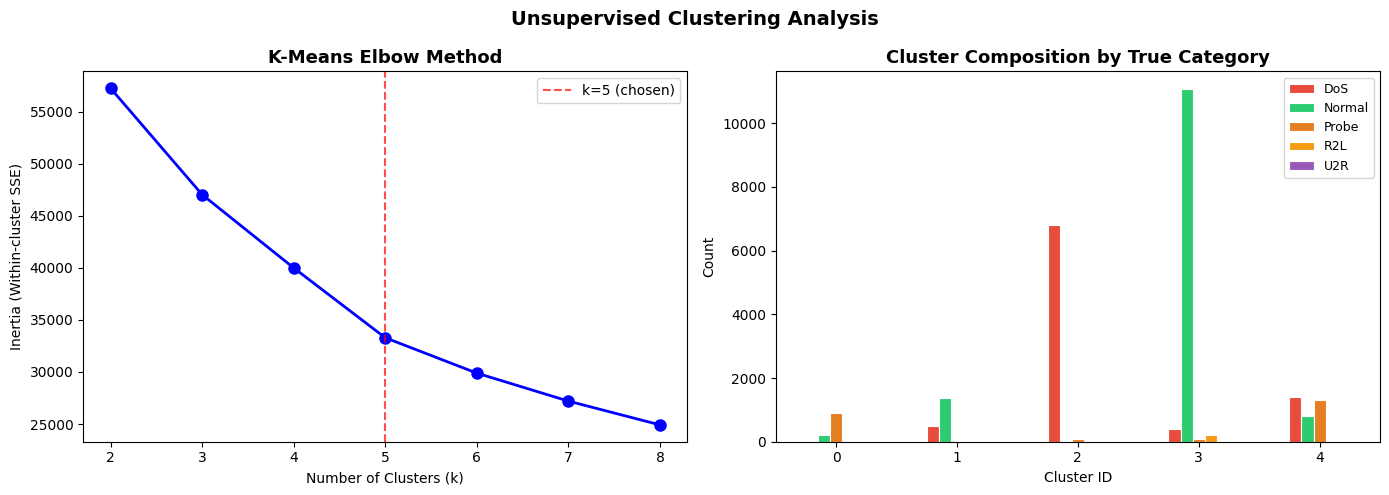

In [26]:
# ══════════════════════════════════════════════════════════
#   UNSUPERVISED — K-MEANS CLUSTERING
# ══════════════════════════════════════════════════════════
print("=" * 60)
print("  K-Means Clustering")
print("=" * 60)
print()

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(X_tr_top)

# Predict cluster membership for validation set
val_clusters  = kmeans.predict(X_val_top)
test_clusters = kmeans.predict(X_test_top)

# Analyse which cluster corresponds to which real category
cluster_df = pd.DataFrame({'cluster': val_clusters, 'true_cat': y_val_m})
cluster_map = cluster_df.groupby('cluster')['true_cat'].agg(lambda x: x.value_counts().index[0])
print("  Cluster → Dominant Category mapping:")
for c, cat in cluster_map.items():
    n_in_cluster = (val_clusters == c).sum()
    print(f"    Cluster {c} → {cat:<10}  ({n_in_cluster:,} samples)")

#  Elbow method to validate k=5 
print()
print("  Running Elbow Method (k=2..8) to confirm optimal k...")
inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=100)
    km.fit(X_tr_top[:5000])   # sample for speed
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(5, color='red', linestyle='--', alpha=0.7, label='k=5 (chosen)')
axes[0].set_title('K-Means Elbow Method', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-cluster SSE)')
axes[0].legend(); axes[0].set_xticks(list(k_range))

# Cluster composition stacked bar
comp = cluster_df.groupby(['cluster','true_cat']).size().unstack(fill_value=0)
comp.plot(kind='bar', ax=axes[1],
          color=[CAT_COLORS.get(c,'grey') for c in comp.columns],
          edgecolor='white', linewidth=0.8)
axes[1].set_title('Cluster Composition by True Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cluster ID'); axes[1].set_ylabel('Count')
axes[1].legend(fontsize=9); axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Unsupervised Clustering Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_analysis.png', dpi=130, bbox_inches='tight')
plt.show()


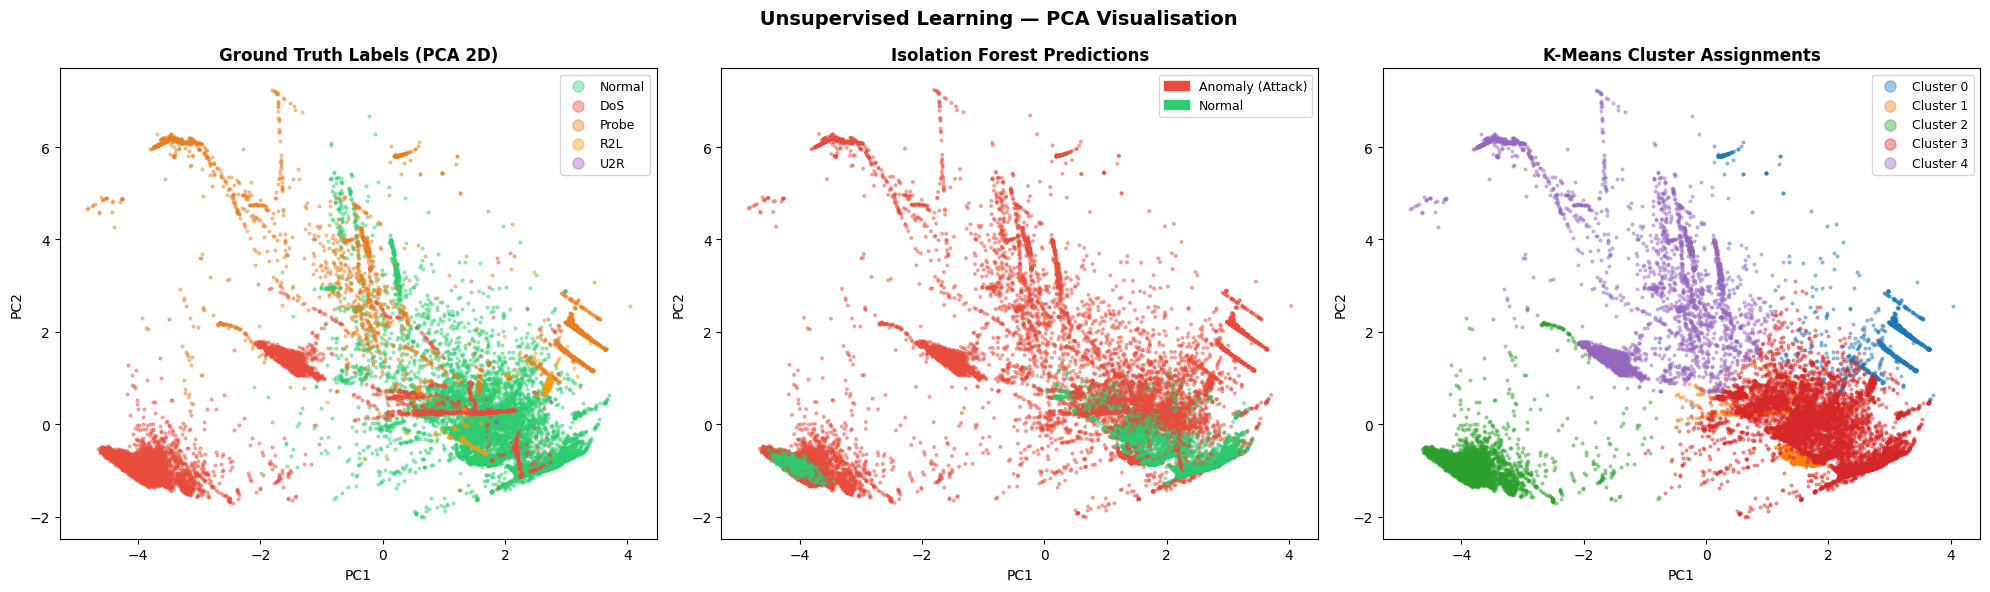

  PCA explained variance: PC1=38.3%, PC2=11.6%


In [11]:
# ══════════════════════════════════════════════════════════
#   UNSUPERVISED — PCA Visualisation
# ══════════════════════════════════════════════════════════

pca = PCA(n_components=2, random_state=42)
X_val_2d = pca.fit_transform(X_val_top)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# True labels
for cat, col in CAT_COLORS.items():
    mask = np.array([c == cat for c in y_val_m])
    if mask.any():
        axes[0].scatter(X_val_2d[mask,0], X_val_2d[mask,1],
                        c=col, s=4, alpha=0.4, label=cat)
axes[0].set_title('Ground Truth Labels (PCA 2D)', fontsize=12, fontweight='bold')
axes[0].legend(markerscale=4, fontsize=9)

# Isolation Forest predictions
c_iso = ['#e74c3c' if p==1 else '#2ecc71' for p in iso_val_pred]
axes[1].scatter(X_val_2d[:,0], X_val_2d[:,1], c=c_iso, s=4, alpha=0.4)
axes[1].set_title('Isolation Forest Predictions', fontsize=12, fontweight='bold')
patches = [mpatches.Patch(color='#e74c3c',label='Anomaly (Attack)'),
           mpatches.Patch(color='#2ecc71',label='Normal')]
axes[1].legend(handles=patches, fontsize=9)

# K-Means clusters
cluster_pal = sns.color_palette('tab10', 5)
for k in range(5):
    mask = val_clusters == k
    axes[2].scatter(X_val_2d[mask,0], X_val_2d[mask,1],
                    c=[cluster_pal[k]], s=4, alpha=0.4, label=f'Cluster {k}')
axes[2].set_title('K-Means Cluster Assignments', fontsize=12, fontweight='bold')
axes[2].legend(markerscale=4, fontsize=9)

for ax in axes: ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.suptitle(' Unsupervised Learning — PCA Visualisation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('unsupervised_pca.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"  PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")


In [12]:
# Handle Unknown attack categories (test set has attacks not in train)
train_enc['attack_category'] = train_enc['attack_category'].replace('Unknown', 'R2L')
test_enc['attack_category']  = test_enc['attack_category'].replace('Unknown', 'R2L')

# ══════════════════════════════════════════════════════════
#   SUPERVISED LAYER — Multi-Class Classification
# ══════════════════════════════════════════════════════════
le_multi  = LabelEncoder()
y_tr_enc  = le_multi.fit_transform(y_tr_m)
y_val_enc = le_multi.transform(y_val_m)
y_test_enc= le_multi.transform(y_test_m)
CLASSES   = le_multi.classes_

print("=" * 65)
print("   Multi-Class Attack Classification")
print("=" * 65)
print(f"  Classes : {list(CLASSES)}")
print(f"  Train   : {len(y_tr_enc):,} | Val: {len(y_val_enc):,} | Test: {len(y_test_enc):,}")
print()

#  Define all supervised models 
SUPERVISED_MODELS = {

    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_leaf=2,
        class_weight='balanced', random_state=42, n_jobs=-1),

    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=42, n_jobs=-1),

    'SVM (RBF)': SVC(
        C=10, kernel='rbf', gamma='scale',
        class_weight='balanced', probability=True, random_state=42),

    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, class_weight='balanced', random_state=42),
}

results    = {}
trained_mdl= {}

print(f"{'Model':<22} {'Accuracy':>10} {'F1-Macro':>10} {'F1-Weighted':>13}")
print("-" * 60)

for name, model in SUPERVISED_MODELS.items():
    t0 = time.time()
    model.fit(X_tr_top, y_tr_enc)
    preds = model.predict(X_val_top)
    elapsed = time.time() - t0

    acc = accuracy_score(y_val_enc, preds)
    f1m = f1_score(y_val_enc, preds, average='macro',    zero_division=0)
    f1w = f1_score(y_val_enc, preds, average='weighted', zero_division=0)
    pre = precision_score(y_val_enc, preds, average='weighted', zero_division=0)
    rec = recall_score(y_val_enc, preds,    average='weighted', zero_division=0)

    results[name]     = {'acc':acc,'f1m':f1m,'f1w':f1w,'pre':pre,'rec':rec,'preds':preds}
    trained_mdl[name] = model
    print(f"{name:<22} {acc:>10.4f} {f1m:>10.4f} {f1w:>13.4f}   [{elapsed:.1f}s]")

BEST = max(results, key=lambda k: results[k]['f1w'])
print(f"\n Best model: {BEST}  (F1-Weighted = {results[BEST]['f1w']:.4f})")

   Multi-Class Attack Classification
  Classes : ['DoS', 'Normal', 'Probe', 'R2L', 'U2R']
  Train   : 100,778 | Val: 25,195 | Test: 22,544

Model                    Accuracy   F1-Macro   F1-Weighted
------------------------------------------------------------
Random Forest              0.9982     0.9085        0.9982   [26.5s]
XGBoost                    0.9988     0.9371        0.9989   [47.2s]
SVM (RBF)                  0.9726     0.7195        0.9767   [750.2s]
Logistic Regression        0.8915     0.6045        0.9122   [33.6s]

 Best model: XGBoost  (F1-Weighted = 0.9989)


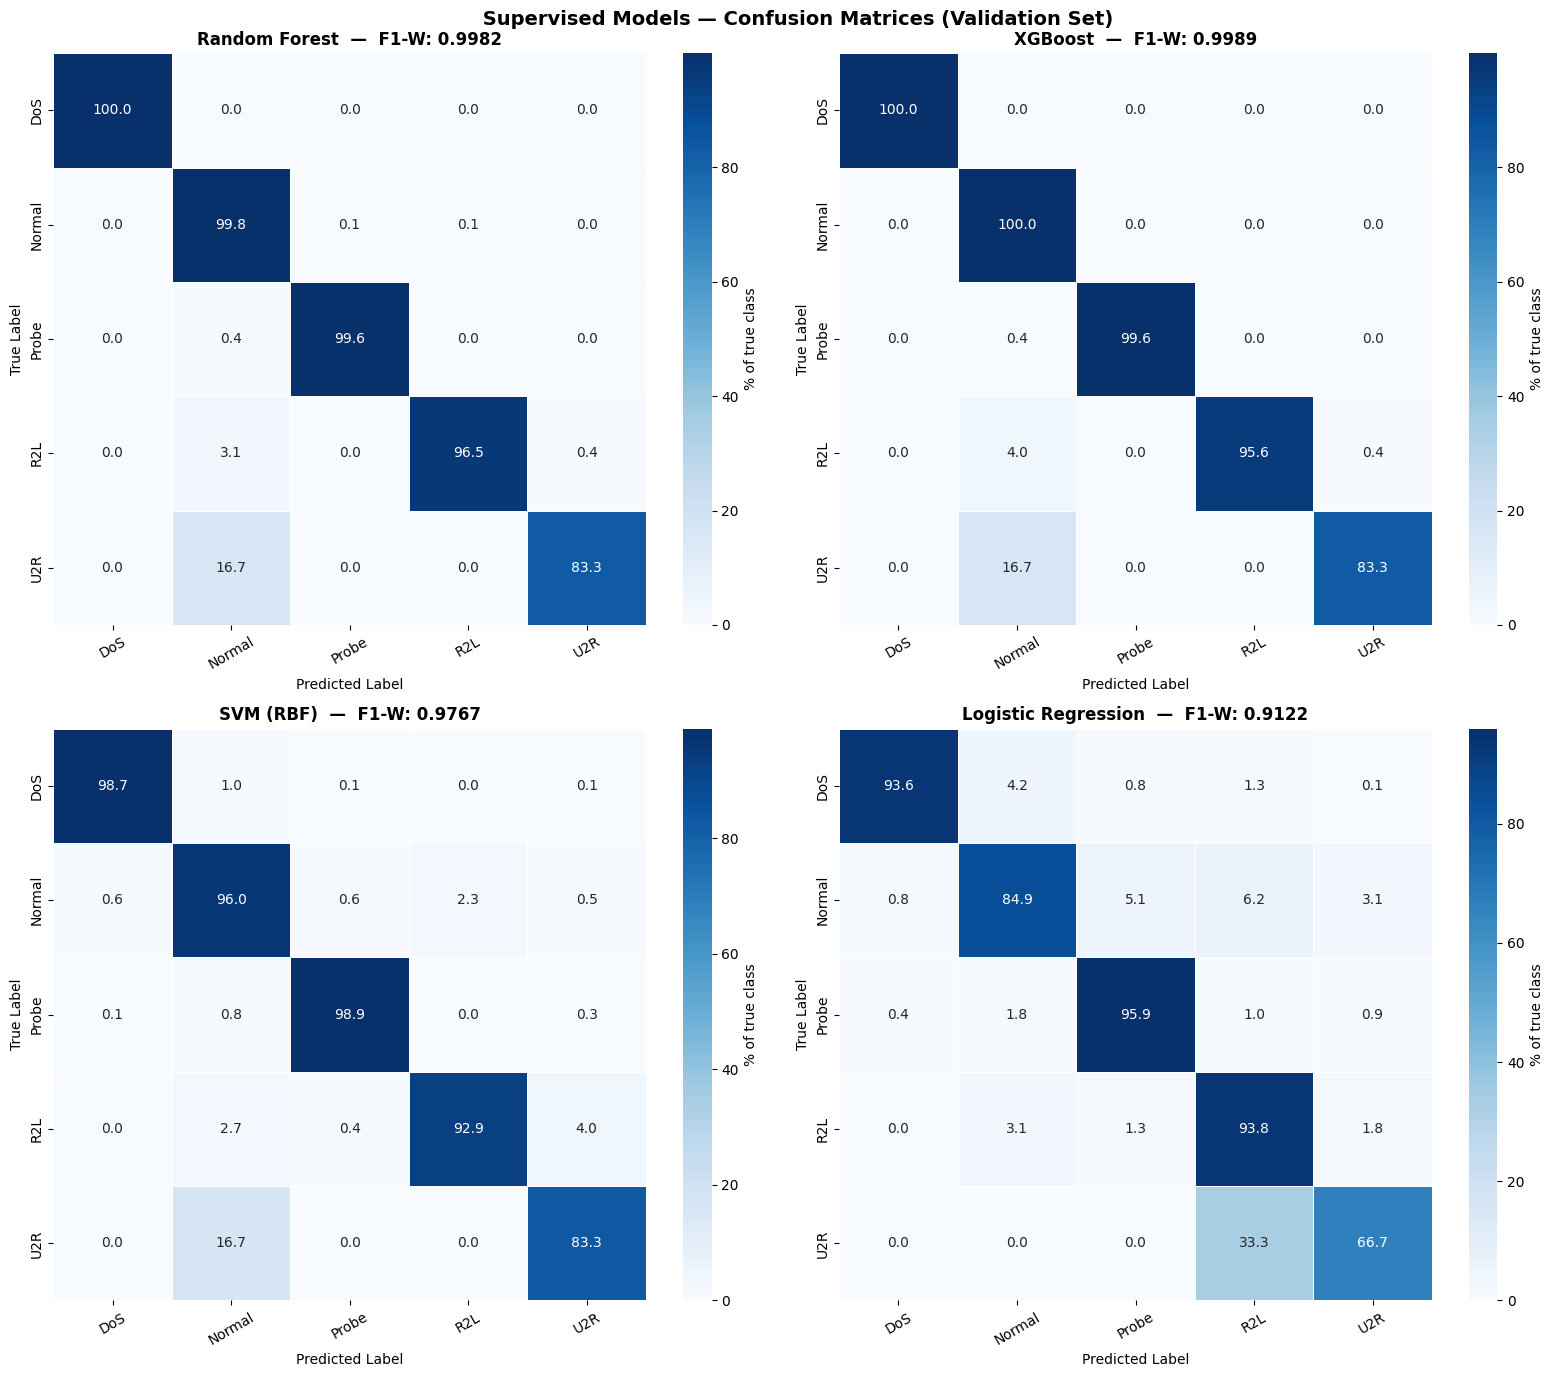

In [13]:
#  Confusion Matrices 
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for ax, (name, res) in zip(axes, results.items()):
    cm  = confusion_matrix(y_val_enc, res['preds'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES,
                ax=ax, linewidths=0.5, cbar_kws={'label':'% of true class'})
    ax.set_title(f'{name}  —  F1-W: {res["f1w"]:.4f}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle(' Supervised Models — Confusion Matrices (Validation Set)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=130, bbox_inches='tight')
plt.show()


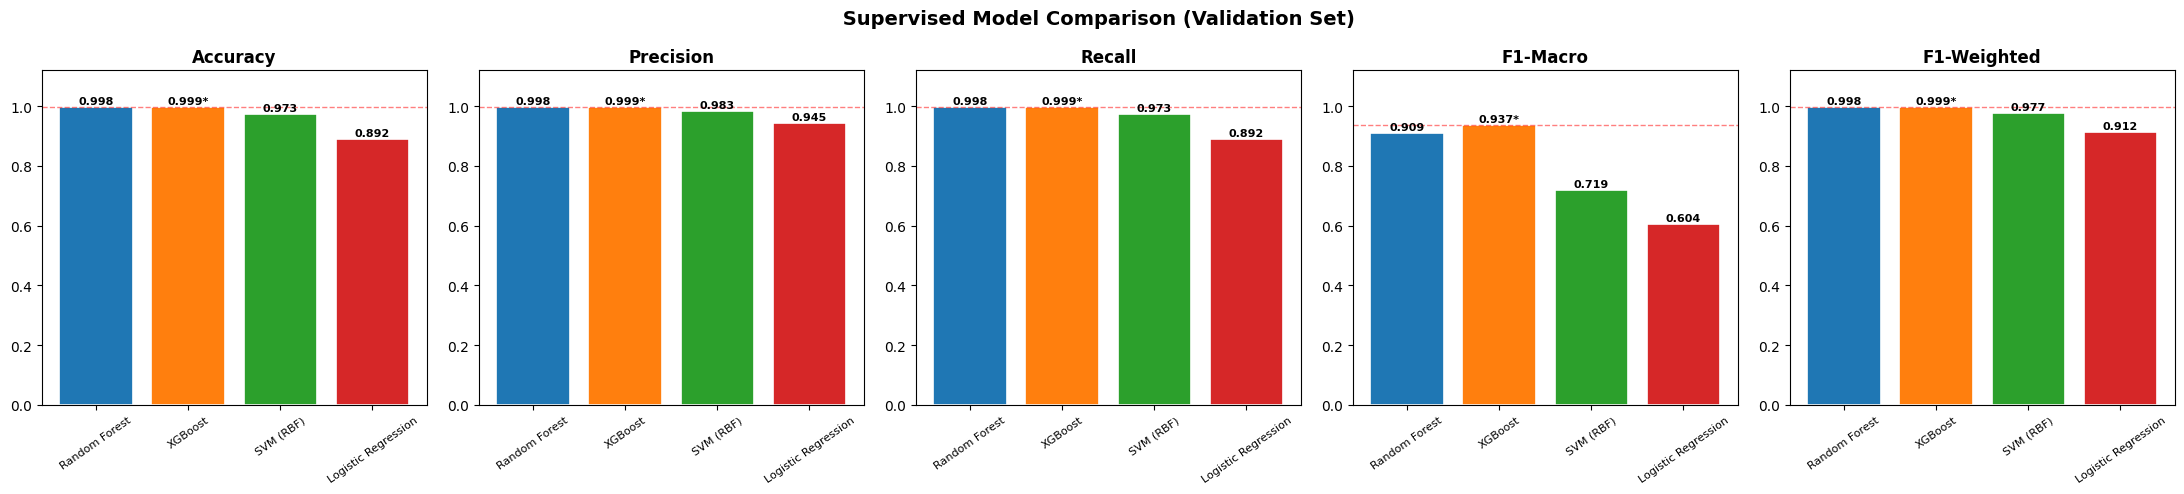

In [14]:
# Model Comparison Chart 
metrics_labels = ['Accuracy','Precision','Recall','F1-Macro','F1-Weighted']
model_names    = list(results.keys())
x = np.arange(len(model_names))
pal = sns.color_palette('tab10', len(model_names))

fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=False)

for ax, metric, label in zip(axes, ['acc','pre','rec','f1m','f1w'], metrics_labels):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=pal, edgecolor='white', linewidth=1.2)
    ax.set_ylim(0, 1.12)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=35, labelsize=8)
    best_v = max(vals)
    ax.axhline(best_v, color='red', linestyle='--', alpha=0.5, linewidth=1)
    for bar, v in zip(bars, vals):
        star = '*' if v == best_v else ''
        ax.text(bar.get_x()+bar.get_width()/2, v+0.01,
                f'{v:.3f}{star}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle(' Supervised Model Comparison (Validation Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

In [15]:
# ══════════════════════════════════════════════════════════
#   HYBRID DECISION ENGINE
#     Fuses Isolation Forest + Best Supervised Model
# ══════════════════════════════════════════════════════════
best_model = trained_mdl[BEST]
print(f"Using best supervised model : {BEST}")
print(f"Fusing with                 : Isolation Forest")
print()

def hybrid_predict(X, iso_model, sup_model, le, alpha=0.30):
    """
    Hybrid decision: supervised classification + unsupervised anomaly detection.

    Parameters
    ----------
    X         : scaled, top-feature matrix
    iso_model : fitted IsolationForest
    sup_model : fitted supervised classifier
    le        : fitted LabelEncoder for class names
    alpha     : weight for anomaly signal (0-1)

    Returns
    -------
    pd.DataFrame with predicted class, anomaly flag, confidence, risk columns
    """
    # Supervised predictions 
    sup_probs      = sup_model.predict_proba(X)
    sup_idx        = np.argmax(sup_probs, axis=1)
    sup_conf       = np.max(sup_probs, axis=1)
    sup_class      = le.inverse_transform(sup_idx)

    # Unsupervised anomaly scores 
    anm_raw   = -iso_model.score_samples(X)
    anm_norm  = (anm_raw - anm_raw.min()) / (anm_raw.max() - anm_raw.min() + 1e-9)
    iso_flag  = (iso_model.predict(X) == -1).astype(int)

    #  Hybrid fusion rule
    # If supervised says Normal BUT isolation forest flags anomaly → Unknown
    contradiction = (iso_flag == 1) & (sup_class == 'Normal')
    final_class   = np.where(contradiction, 'Unknown (Zero-Day)', sup_class)

    # Fused confidence: penalised when models disagree
    fused_conf = (1 - alpha) * sup_conf + alpha * (1 - anm_norm)
    fused_conf = np.clip(fused_conf, 0, 1)

    return pd.DataFrame({
        'predicted_class'   : final_class,
        'supervised_class'  : sup_class,
        'anomaly_flag'      : iso_flag,
        'anomaly_score'     : anm_norm.round(4),
        'sup_confidence'    : sup_conf.round(4),
        'hybrid_confidence' : fused_conf.round(4),
    })

# Run on test set
hybrid_df = hybrid_predict(X_test_top, iso_forest, best_model, le_multi)
hybrid_df['true_class'] = y_test_m

# Accuracy — compare supervised output to true labels
hybrid_acc = accuracy_score(
    hybrid_df['true_class'],
    hybrid_df['supervised_class']
)
zero_day_count = (hybrid_df['predicted_class'] == 'Unknown (Zero-Day)').sum()

print(f"Hybrid Engine — Test Set Results:")
print(f"  Supervised accuracy      : {hybrid_acc:.4f}")
print(f"  Zero-day flags raised    : {zero_day_count:,}")
print(f"  Anomaly flags total      : {hybrid_df['anomaly_flag'].sum():,}")
print()
print(hybrid_df.head(10).to_string(index=False))

Using best supervised model : XGBoost
Fusing with                 : Isolation Forest

Hybrid Engine — Test Set Results:
  Supervised accuracy      : 0.7602
  Zero-day flags raised    : 4,813
  Anomaly flags total      : 11,951

   predicted_class supervised_class  anomaly_flag  anomaly_score  sup_confidence  hybrid_confidence true_class
               DoS              DoS             1          0.234           1.000              0.930        DoS
               DoS              DoS             1          0.242           1.000              0.927        DoS
Unknown (Zero-Day)           Normal             1          0.256           1.000              0.923     Normal
             Probe            Probe             1          0.372           0.994              0.884      Probe
Unknown (Zero-Day)           Normal             1          0.547           0.999              0.835      Probe
            Normal           Normal             0          0.116           1.000              0.965     No

Class Distribution in Training Set:
--------------------------------------------------
  Normal      53,874 samples  (53.46%)  weight=0.37
  DoS         36,822 samples  (36.54%)  weight=0.55
  Probe        9,267 samples  ( 9.20%)  weight=2.17
  R2L            769 samples  ( 0.76%)  weight=26.21
  U2R             46 samples  ( 0.05%)  weight=438.17


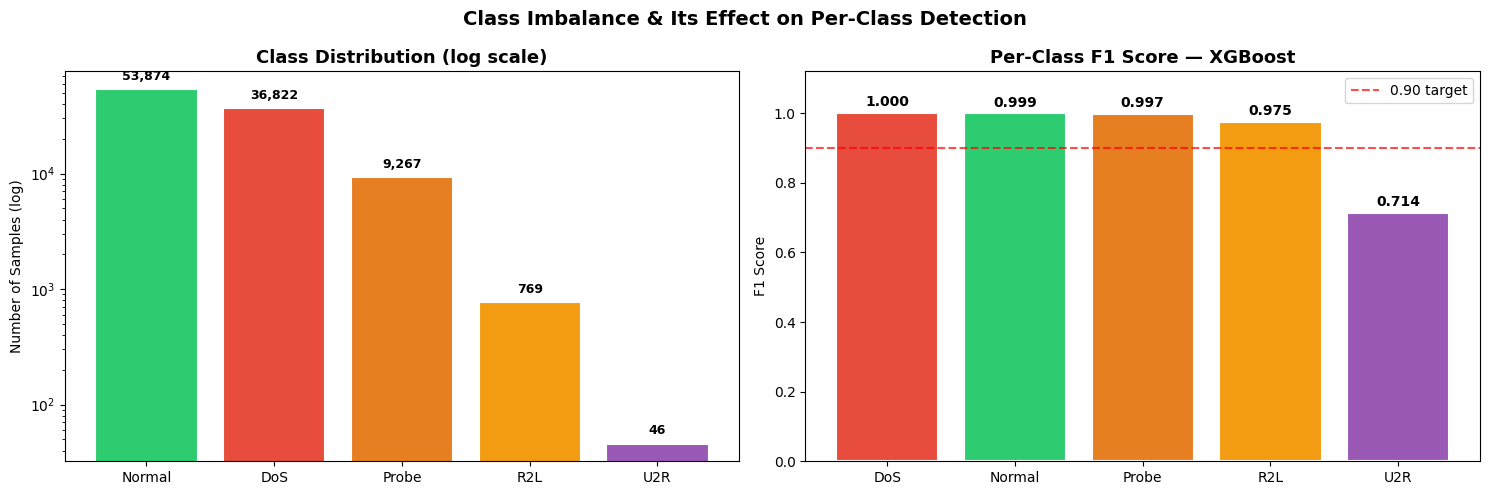

In [16]:
# ══════════════════════════════════════════════════════════
#   CLASS IMBALANCE ANALYSIS
# ══════════════════════════════════════════════════════════
print("Class Distribution in Training Set:")
print("-" * 50)
class_counts = pd.Series(y_tr_m).value_counts()
total = len(y_tr_m)
for cls, cnt in class_counts.items():
    ratio = total / (len(class_counts) * cnt)   # balanced weight
    print(f"  {cls:<10} {cnt:>7,} samples  ({cnt/total*100:5.2f}%)  weight={ratio:.2f}")

# Visual: imbalance + effect on per-class F1 
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Class distribution
axes[0].bar(class_counts.index, class_counts.values,
            color=[CAT_COLORS.get(c,'grey') for c in class_counts.index],
            edgecolor='white', linewidth=1.5)
axes[0].set_yscale('log')
axes[0].set_title('Class Distribution (log scale)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Samples (log)')
for i, (cls, cnt) in enumerate(class_counts.items()):
    axes[0].text(i, cnt*1.2, f'{cnt:,}', ha='center', fontsize=9, fontweight='bold')

# Per-class F1 for best model
best_preds_val = results[BEST]['preds']
per_class_f1   = f1_score(y_val_enc, best_preds_val, average=None, zero_division=0)
axes[1].bar(CLASSES, per_class_f1,
            color=[CAT_COLORS.get(c,'grey') for c in CLASSES],
            edgecolor='white', linewidth=1.5)
axes[1].axhline(0.9, color='red', linestyle='--', alpha=0.7, label='0.90 target')
axes[1].set_title(f'Per-Class F1 Score — {BEST}', fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1.12)
axes[1].legend(fontsize=10)
for i, (cls, f1v) in enumerate(zip(CLASSES, per_class_f1)):
    axes[1].text(i, f1v+0.02, f'{f1v:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Class Imbalance & Its Effect on Per-Class Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=130, bbox_inches='tight')
plt.show()


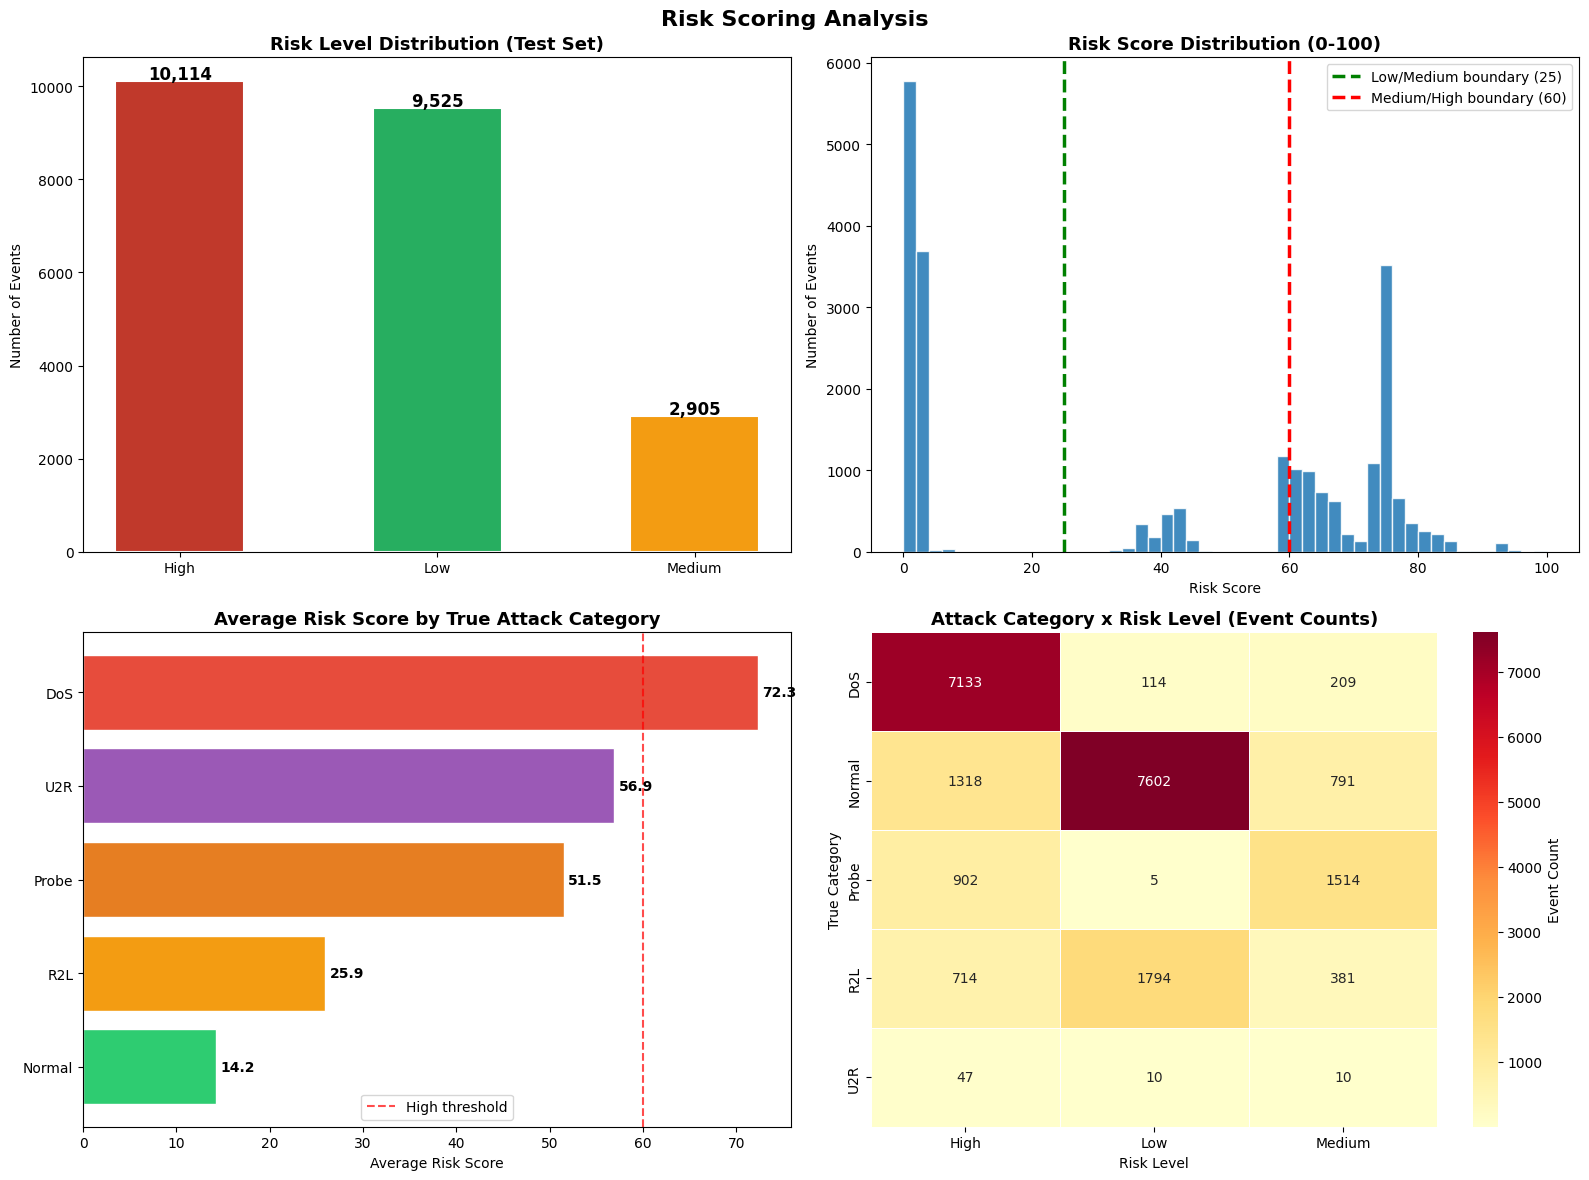

Risk Level Summary:
  High    : 10,114 events  (44.9%)
  Low     :  9,525 events  (42.3%)
  Medium  :  2,905 events  (12.9%)


In [17]:
# RISK SCORING MODULE
SEVERITY = {
    'Normal':              0,
    'Probe':              30,
    'DoS':                70,
    'R2L':                85,
    'U2R':               100,
    'Unknown (Zero-Day)': 55,
}

def compute_risk(row):
    """Calculate final risk score (0-100) for one network event."""
    base         = SEVERITY.get(row['predicted_class'], 50)
    anm_boost    = row['anomaly_score'] * 15
    conf_penalty = (1 - row['hybrid_confidence']) * 10
    return min(100.0, round(base + anm_boost + conf_penalty, 1))

def risk_level(score):
    if   score < 25: return 'Low'
    elif score < 60: return 'Medium'
    else:            return 'High'

hybrid_df['risk_score'] = hybrid_df.apply(compute_risk, axis=1)
hybrid_df['risk_level'] = hybrid_df['risk_score'].apply(risk_level)

# Risk Distribution Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Risk level bar
rl_vc = hybrid_df['risk_level'].value_counts()
rc    = [RISK_COLORS.get(r, 'grey') for r in rl_vc.index]
bars  = axes[0, 0].bar(rl_vc.index, rl_vc.values, color=rc, edgecolor='white', linewidth=1.5, width=0.5)
axes[0, 0].set_title('Risk Level Distribution (Test Set)', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Number of Events')
for bar, v in zip(bars, rl_vc.values):
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, v + 50,
                    f'{v:,}', ha='center', fontweight='bold', fontsize=12)

# 2. Risk score histogram
axes[0, 1].hist(hybrid_df['risk_score'], bins=50, edgecolor='white', alpha=0.85)
axes[0, 1].axvline(25, color='green', linestyle='--', linewidth=2.5, label='Low/Medium boundary (25)')
axes[0, 1].axvline(60, color='red',   linestyle='--', linewidth=2.5, label='Medium/High boundary (60)')
axes[0, 1].set_title('Risk Score Distribution (0-100)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Risk Score')
axes[0, 1].set_ylabel('Number of Events')
axes[0, 1].legend(fontsize=10)

# 3. Avg risk per true category
avg_risk   = hybrid_df.groupby('true_class')['risk_score'].mean().sort_values(ascending=True)
cat_colors = [CAT_COLORS.get(c, '#7f8c8d') for c in avg_risk.index]
axes[1, 0].barh(avg_risk.index, avg_risk.values, color=cat_colors, edgecolor='white')
axes[1, 0].set_title('Average Risk Score by True Attack Category', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Average Risk Score')
axes[1, 0].axvline(60, color='red', linestyle='--', alpha=0.7, label='High threshold')
for i, (cat, val) in enumerate(avg_risk.items()):
    axes[1, 0].text(val + 0.5, i, f'{val:.1f}', va='center', fontsize=10, fontweight='bold')
axes[1, 0].legend()

# 4. Category vs Risk Level heatmap
pivot = hybrid_df.pivot_table(values='risk_score', index='true_class',
                               columns='risk_level', aggfunc='count', fill_value=0)
sns.heatmap(pivot, ax=axes[1, 1], cmap='YlOrRd', annot=True, fmt='d',
            linewidths=0.5, cbar_kws={'label': 'Event Count'})
axes[1, 1].set_title('Attack Category x Risk Level (Event Counts)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Risk Level')
axes[1, 1].set_ylabel('True Category')

plt.suptitle('Risk Scoring Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('risk_scoring.png', dpi=130, bbox_inches='tight')
plt.show()

# Risk Level Summary
print("Risk Level Summary:")
for level, cnt in rl_vc.items():
    print(f"  {level:<8}: {cnt:>6,} events  ({cnt / len(hybrid_df) * 100:.1f}%)")

Running 5-Fold Stratified Cross-Validation...
(Using a 20% sample for speed — scale up for full evaluation)

Model                     Mean F1     Std F1     Min F1     Max F1
-----------------------------------------------------------------
Random Forest              0.9911     0.0020     0.9886     0.9935
XGBoost                    0.9919     0.0023     0.9886     0.9948
Logistic Regression        0.9218     0.0037     0.9176     0.9271


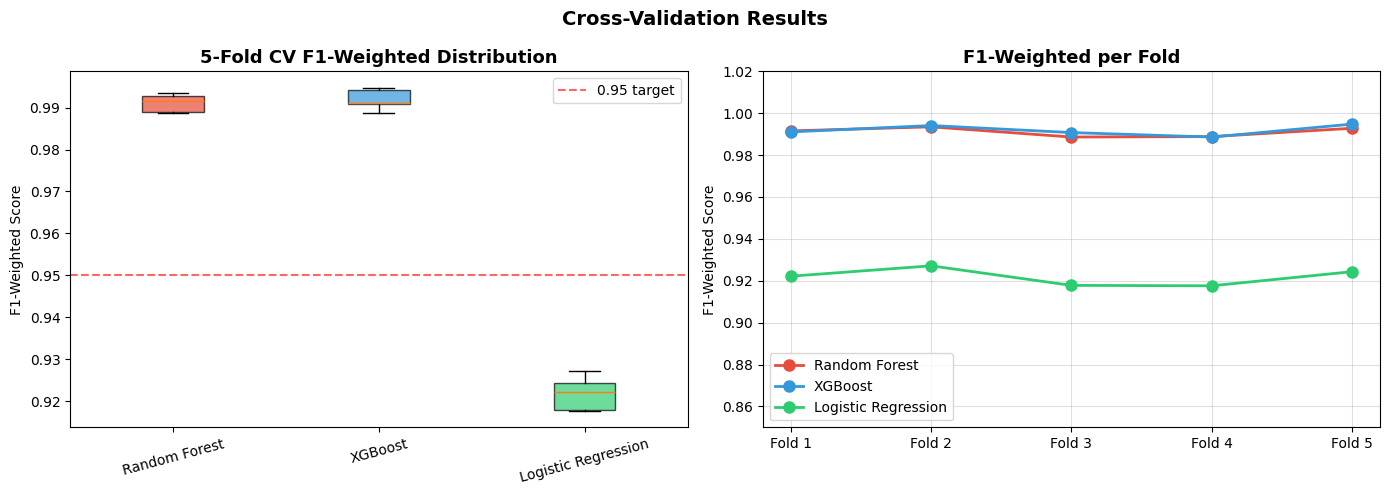

In [18]:
# ══════════════════════════════════════════════════════════
#   5-FOLD STRATIFIED CROSS-VALIDATION
# ══════════════════════════════════════════════════════════
from sklearn.model_selection import StratifiedKFold, cross_val_score

print("Running 5-Fold Stratified Cross-Validation...")
print("(Using a 20% sample for speed — scale up for full evaluation)")
print()

# Use a stratified sample for speed
sample_idx = []
le_cv = LabelEncoder()
y_all_enc = le_cv.fit_transform(y_multi)

for cls in np.unique(y_all_enc):
    idx = np.where(y_all_enc == cls)[0]
    n_sample = min(len(idx), 3000)
    sample_idx.extend(np.random.choice(idx, n_sample, replace=False))

sample_idx = np.array(sample_idx)
X_cv = X_scaled[sample_idx][:, top_idx]
y_cv = y_all_enc[sample_idx]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Random Forest':      RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost':            XGBClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1, eval_metric='mlogloss'),
    'Logistic Regression':LogisticRegression(C=1.0, max_iter=500, class_weight='balanced', random_state=42),
}

cv_results = {}
print(f"{'Model':<22} {'Mean F1':>10} {'Std F1':>10} {'Min F1':>10} {'Max F1':>10}")
print("-" * 65)

for name, model in cv_models.items():
    scores = cross_val_score(model, X_cv, y_cv, cv=skf,
                             scoring='f1_weighted', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:<22} {scores.mean():>10.4f} {scores.std():>10.4f} {scores.min():>10.4f} {scores.max():>10.4f}")

#  Plot CV results 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
cv_data   = [cv_results[m] for m in cv_models]
cv_labels = list(cv_models.keys())
bp = axes[0].boxplot(cv_data, patch_artist=True, labels=cv_labels)
for patch, col in zip(bp['boxes'], ['#e74c3c','#3498db','#2ecc71']):
    patch.set_facecolor(col); patch.set_alpha(0.7)
axes[0].set_title('5-Fold CV F1-Weighted Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('F1-Weighted Score')
axes[0].tick_params(axis='x', rotation=15)
axes[0].axhline(0.95, color='red', linestyle='--', alpha=0.6, label='0.95 target')
axes[0].legend()

# Line chart per fold
folds = [f'Fold {i+1}' for i in range(5)]
for (name, scores), col in zip(cv_results.items(), ['#e74c3c','#3498db','#2ecc71']):
    axes[1].plot(folds, scores, 'o-', label=name, color=col, linewidth=2, markersize=8)
axes[1].set_title('F1-Weighted per Fold', fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1-Weighted Score')
axes[1].set_ylim(0.85, 1.02)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.4)

plt.suptitle('Cross-Validation Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cross_validation.png', dpi=130, bbox_inches='tight')
plt.show()


In [19]:
print("=" * 65)
print("  CLASSIFICATION REPORT — Best Supervised Model on Test Set")
print("=" * 65)
test_preds = best_model.predict(X_test_top)
test_labels_decoded = le_multi.inverse_transform(test_preds)
print(classification_report(y_test_m, test_labels_decoded, zero_division=0))

print("\nPer-Model Summary (Validation Set):")
print(f"{'Model':<22} {'Acc':>7} {'F1-M':>7} {'F1-W':>7} {'Pre':>7} {'Rec':>7}")
print("-" * 60)
for name, res in results.items():
    mark = " ← BEST" if name == BEST else ""
    print(f"{name:<22} {res['acc']:>7.4f} {res['f1m']:>7.4f} {res['f1w']:>7.4f} "
          f"{res['pre']:>7.4f} {res['rec']:>7.4f}{mark}")

print("\nIsolation Forest (Unsupervised):")
print(f"  Accuracy  : {iso_acc:.4f}")
print(f"  F1 Score  : {iso_f1:.4f}")
print(f"  Precision : {iso_pre:.4f}")
print(f"  Recall    : {iso_rec:.4f}")

  CLASSIFICATION REPORT — Best Supervised Model on Test Set
              precision    recall  f1-score   support

         DoS       0.96      0.82      0.88      7456
      Normal       0.66      0.97      0.78      9711
       Probe       0.87      0.62      0.72      2421
         R2L       0.98      0.04      0.08      2889
         U2R       0.62      0.07      0.13        67

    accuracy                           0.76     22544
   macro avg       0.82      0.51      0.52     22544
weighted avg       0.82      0.76      0.72     22544


Per-Model Summary (Validation Set):
Model                      Acc    F1-M    F1-W     Pre     Rec
------------------------------------------------------------
Random Forest           0.9982  0.9085  0.9982  0.9983  0.9982
XGBoost                 0.9988  0.9371  0.9989  0.9989  0.9988 ← BEST
SVM (RBF)               0.9726  0.7195  0.9767  0.9831  0.9726
Logistic Regression     0.8915  0.6045  0.9122  0.9446  0.8915

Isolation Forest (Unsupervised

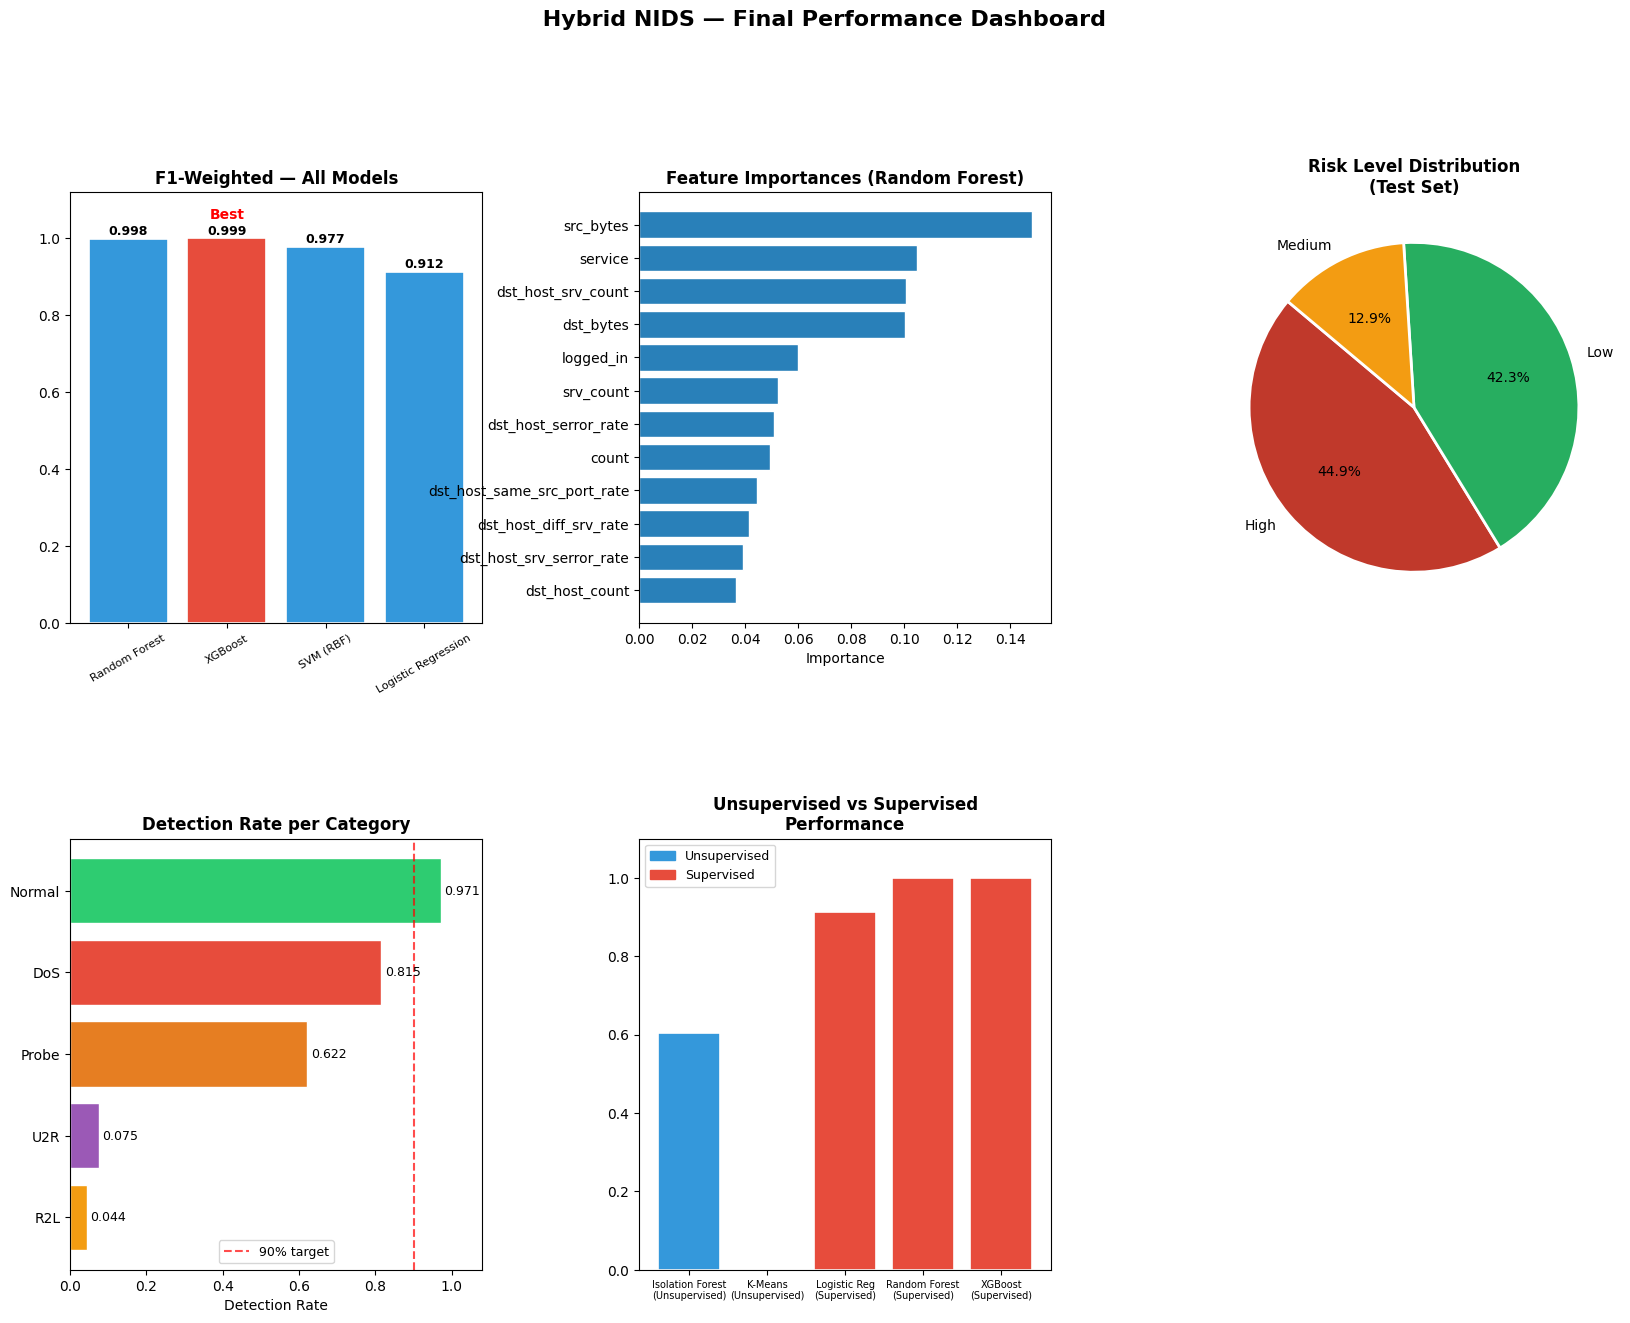

In [ ]:
#  Final Performance Dashboard
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, hspace=0.50, wspace=0.38)

# 1. Model F1-W comparison
ax1 = fig.add_subplot(gs[0, 0])
names_s = list(results.keys())
f1w_vals= [results[m]['f1w'] for m in names_s]
bar_cols = ['#e74c3c' if m==BEST else '#3498db' for m in names_s]
bars = ax1.bar(names_s, f1w_vals, color=bar_cols, edgecolor='white', linewidth=1.2)
ax1.set_title('F1-Weighted — All Models', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 1.12)
ax1.tick_params(axis='x', rotation=30, labelsize=8)
for bar, v in zip(bars, f1w_vals):
    ax1.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax1.annotate('Best', xy=(names_s.index(BEST), results[BEST]['f1w']+0.05),
             color='red', ha='center', fontsize=10, fontweight='bold')

# 2. RF Feature importances
ax2 = fig.add_subplot(gs[0, 1])
rf = trained_mdl.get('Random Forest') or trained_mdl.get('XGBoost')
if hasattr(rf, 'feature_importances_'):
    fi = pd.Series(rf.feature_importances_, index=TOP_FEATS).nlargest(12)
    ax2.barh(fi.index[::-1], fi.values[::-1], color='#2980b9', edgecolor='white')
    ax2.set_title('Feature Importances (Random Forest)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Importance')

# 3. Risk level pie
ax3 = fig.add_subplot(gs[0, 2])
rl_vc2 = hybrid_df['risk_level'].value_counts()
ax3.pie(rl_vc2.values, labels=rl_vc2.index,
        colors=[RISK_COLORS.get(r,'grey') for r in rl_vc2.index],
        autopct='%1.1f%%', startangle=140,
        wedgeprops={'edgecolor':'white','linewidth':2})
ax3.set_title('Risk Level Distribution\n(Test Set)', fontsize=12, fontweight='bold')

# 4. Detection rate per category
ax4 = fig.add_subplot(gs[1, 0])
det = []
for cat in CLASSES:
    mask = np.array(y_test_m) == cat
    if mask.sum() == 0: continue
    preds_cat = le_multi.inverse_transform(best_model.predict(X_test_top[mask]))
    dr = (preds_cat == cat).mean()
    det.append({'Category': cat, 'Rate': dr})
det_df = pd.DataFrame(det).sort_values('Rate')
ax4.barh(det_df['Category'], det_df['Rate'],
         color=[CAT_COLORS.get(c,'grey') for c in det_df['Category']], edgecolor='white')
ax4.axvline(0.9, color='red', linestyle='--', alpha=0.7, label='90% target')
ax4.set_title('Detection Rate per Category', fontsize=12, fontweight='bold')
ax4.set_xlabel('Detection Rate'); ax4.set_xlim(0, 1.08)
ax4.legend(fontsize=9)
for _, row in det_df.iterrows():
    ax4.text(row['Rate']+0.01, list(det_df['Category']).index(row['Category']),
             f"{row['Rate']:.3f}", va='center', fontsize=9)

# 5. Unsupervised vs Supervised comparison
ax5 = fig.add_subplot(gs[1, 1])
comp_data = {
    'Method': ['Isolation Forest\n(Unsupervised)','K-Means\n(Unsupervised)',
               'Logistic Reg\n(Supervised)','Random Forest\n(Supervised)','XGBoost\n(Supervised)'],
    'F1': [iso_f1, 0,
           results.get('Logistic Regression',{}).get('f1w',0),
           results.get('Random Forest',{}).get('f1w',0),
           results.get('XGBoost',{}).get('f1w',0)],
    'Type': ['Unsupervised','Unsupervised','Supervised','Supervised','Supervised']
}
cd = pd.DataFrame(comp_data)
bar_c2 = ['#3498db' if t=='Unsupervised' else '#e74c3c' for t in cd['Type']]
ax5.bar(cd['Method'], cd['F1'], color=bar_c2, edgecolor='white', linewidth=1.2)
ax5.set_title('Unsupervised vs Supervised\nPerformance', fontsize=12, fontweight='bold')
ax5.set_ylim(0, 1.1)
ax5.tick_params(axis='x', labelsize=7)
patches = [mpatches.Patch(color='#3498db',label='Unsupervised'),
           mpatches.Patch(color='#e74c3c',label='Supervised')]
ax5.legend(handles=patches, fontsize=9)



plt.suptitle(' Hybrid NIDS — Final Performance Dashboard', fontsize=16, fontweight='bold', y=1.01)
plt.savefig('final_dashboard.png', dpi=130, bbox_inches='tight')
plt.show()


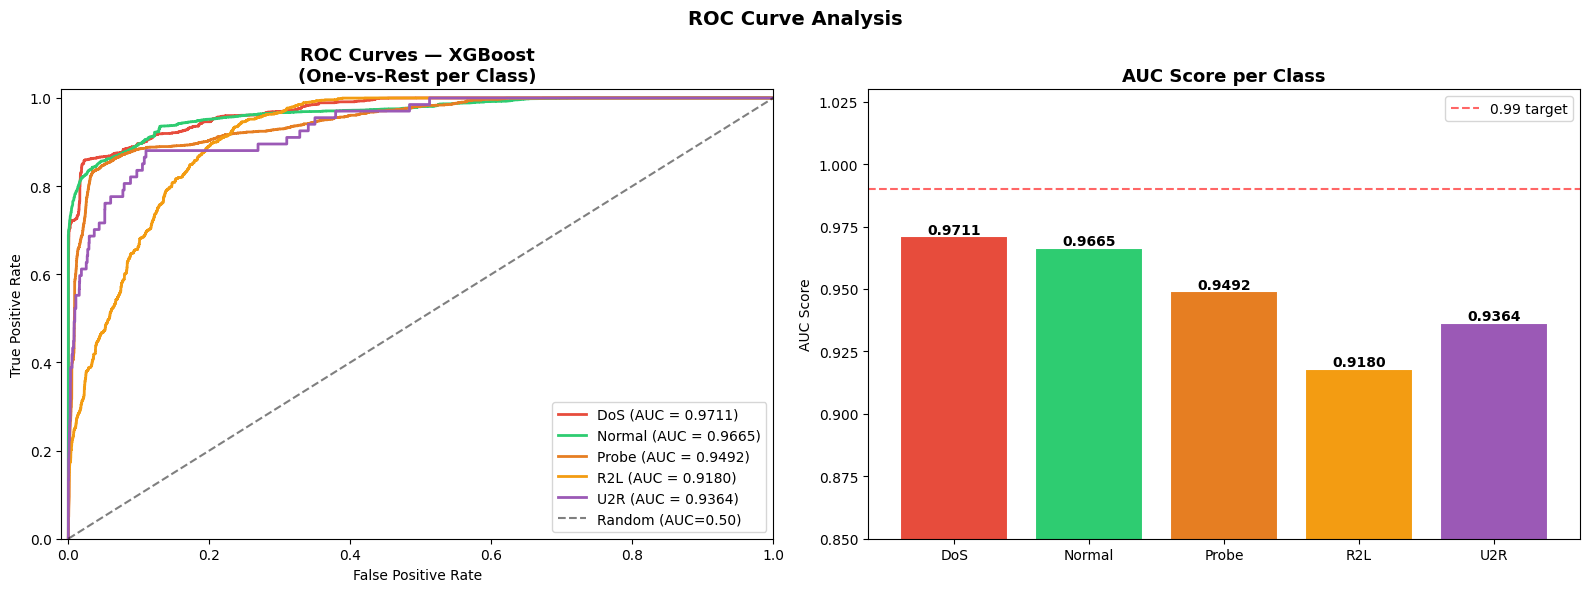

AUC Scores per Class:
  DoS         AUC = 0.9711  Good
  Normal      AUC = 0.9665  Good
  Probe       AUC = 0.9492  Needs work
  R2L         AUC = 0.9180  Needs work
  U2R         AUC = 0.9364  Needs work

  Mean AUC: 0.9482


In [21]:
# ROC CURVES — One-vs-Rest for each attack category
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize labels for OvR ROC
y_test_bin_multi = label_binarize(y_test_m, classes=list(CLASSES))

# Get probabilities from best model
y_prob = best_model.predict_proba(X_test_top)

# Plot ROC curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Per-class ROC on ax[0]
auc_scores = {}
for i, cls in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(y_test_bin_multi[:, i], y_prob[:, i])
    roc_auc     = auc(fpr, tpr)
    auc_scores[cls] = roc_auc
    axes[0].plot(fpr, tpr, linewidth=2,
                 color=CAT_COLORS.get(cls, 'grey'),
                 label=f'{cls} (AUC = {roc_auc:.4f})')

axes[0].plot([0,1],[0,1],'k--', alpha=0.5, label='Random (AUC=0.50)')
axes[0].set_title(f'ROC Curves — {BEST}\n(One-vs-Rest per Class)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=10)
axes[0].set_xlim([-0.01, 1.0])
axes[0].set_ylim([0.0, 1.02])

# AUC bar chart on ax[1]
auc_vals = [auc_scores[c] for c in CLASSES]
bars = axes[1].bar(CLASSES, auc_vals,
                   color=[CAT_COLORS.get(c, 'grey') for c in CLASSES],
                   edgecolor='white', linewidth=1.5)
axes[1].set_ylim(0.85, 1.03)
axes[1].set_title('AUC Score per Class', fontsize=13, fontweight='bold')
axes[1].set_ylabel('AUC Score')
axes[1].axhline(0.99, color='red', linestyle='--', alpha=0.6, label='0.99 target')
axes[1].legend()
for bar, v in zip(bars, auc_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.001,
                 f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('ROC Curve Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=130, bbox_inches='tight')
plt.show()

print("AUC Scores per Class:")
for cls, score in auc_scores.items():
    quality = 'Excellent' if score >= 0.99 else 'Good' if score >= 0.95 else 'Needs work'
    print(f"  {cls:<10}  AUC = {score:.4f}  {quality}")
print(f"\n  Mean AUC: {np.mean(list(auc_scores.values())):.4f}")

In [22]:
# REAL-TIME INFERENCE — process one event at a time
# Simulates how the system handles live network traffic

def predict_event(event_dict, iso_model, sup_model, le, scaler_obj, feat_cols, top_ix, alpha=0.30):
    """Process a single network event through the full hybrid pipeline."""
    t0 = time.time()
    vec = np.array([[event_dict.get(f, 0) for f in feat_cols]])
    vec_sc  = scaler_obj.transform(vec)
    vec_top = vec_sc[:, top_ix]

    # Unsupervised
    iso_flag  = int(iso_model.predict(vec_top)[0] == -1)
    anm_raw   = float(-iso_model.score_samples(vec_top)[0])

    # Supervised
    probs     = sup_model.predict_proba(vec_top)[0]
    sup_idx   = int(np.argmax(probs))
    sup_cls   = le.inverse_transform([sup_idx])[0]
    sup_conf  = float(probs[sup_idx])

    # Hybrid
    if iso_flag and sup_cls == 'Normal':
        final_cls = 'Unknown (Zero-Day)'
    else:
        final_cls = sup_cls

    base  = SEVERITY.get(final_cls, 50)
    anm_n = min(1.0, anm_raw)
    score = min(100.0, round(base + anm_n*15 + (1-sup_conf)*10, 1))
    level = risk_level(score)

    return {
        'detected_class' : final_cls,
        'risk_level'     : level,
        'risk_score'     : score,
        'anomaly_flag'   : bool(iso_flag),
        'sup_confidence' : round(sup_conf, 4),
        'latency_ms'     : round((time.time()-t0)*1000, 2)
    }

# 6 Demo events (one per scenario)
demo_events = [
    {'duration':0,'src_bytes':491,'dst_bytes':0,'count':511,'serror_rate':0.99,
     'same_srv_rate':1.0,'logged_in':0,'protocol_type':1,'service':2,'flag':2,
     '_label':'DoS (neptune-style)'},
    {'duration':120,'src_bytes':28000,'dst_bytes':15000,'count':5,'serror_rate':0.0,
     'same_srv_rate':0.95,'logged_in':1,'protocol_type':0,'service':0,'flag':3,
     '_label':'Normal HTTP Session'},
    {'duration':0,'src_bytes':50,'dst_bytes':0,'count':350,'diff_srv_rate':0.87,
     'same_srv_rate':0.02,'serror_rate':0.0,'logged_in':0,'protocol_type':2,
     'service':3,'flag':1,'_label':'Probe (portsweep)'},
    {'duration':2,'src_bytes':1000,'dst_bytes':500,'num_failed_logins':5,
     'logged_in':0,'count':3,'serror_rate':0.0,'protocol_type':1,'service':1,
     'flag':3,'_label':'R2L (guess_passwd)'},
    {'duration':0,'src_bytes':1200,'dst_bytes':200,'root_shell':1,'num_compromised':8,
     'num_root':4,'hot':22,'logged_in':1,'count':2,'protocol_type':1,
     'service':4,'flag':3,'_label':'U2R (buffer_overflow)'},
    {'duration':9999,'src_bytes':99999,'dst_bytes':99999,'count':1,'serror_rate':0.5,
     'wrong_fragment':3,'urgent':1,'protocol_type':2,'service':10,'flag':4,
     '_label':'Unusual Traffic (Zero-Day?)'},
]

print("=" * 68)
print("  REAL-TIME INFERENCE SIMULATOR")
print("  Processing one network event at a time through the hybrid pipeline")
print("=" * 68)
print()

for i, ev in enumerate(demo_events, 1):
    label  = ev.pop('_label')
    result = predict_event(ev, iso_forest, best_model, le_multi, scaler, FEAT_COLS, top_idx)
    print(f"Event {i}: {label}")
    print(f"  Detected : {result['detected_class']}")
    print(f"  Risk     : {result['risk_level']}  (Score = {result['risk_score']}/100)")
    print(f"  Anomaly  : {'YES' if result['anomaly_flag'] else 'NO'}   "
          f"Confidence: {result['sup_confidence']:.4f}   Latency: {result['latency_ms']} ms")
    print()

  REAL-TIME INFERENCE SIMULATOR
  Processing one network event at a time through the hybrid pipeline

Event 1: DoS (neptune-style)
  Detected : Unknown (Zero-Day)
  Risk     : High  (Score = 67.9/100)
  Anomaly  : YES   Confidence: 0.5944   Latency: 3393.62 ms

Event 2: Normal HTTP Session
  Detected : Unknown (Zero-Day)
  Risk     : High  (Score = 63.1/100)
  Anomaly  : YES   Confidence: 0.9920   Latency: 205.61 ms

Event 3: Probe (portsweep)
  Detected : Unknown (Zero-Day)
  Risk     : High  (Score = 63.9/100)
  Anomaly  : YES   Confidence: 0.9700   Latency: 190.7 ms

Event 4: R2L (guess_passwd)
  Detected : Unknown (Zero-Day)
  Risk     : High  (Score = 62.9/100)
  Anomaly  : YES   Confidence: 0.9960   Latency: 145.74 ms

Event 5: U2R (buffer_overflow)
  Detected : Unknown (Zero-Day)
  Risk     : High  (Score = 62.8/100)
  Anomaly  : YES   Confidence: 0.9933   Latency: 217.5 ms

Event 6: Unusual Traffic (Zero-Day?)
  Detected : Unknown (Zero-Day)
  Risk     : High  (Score = 64.6/100

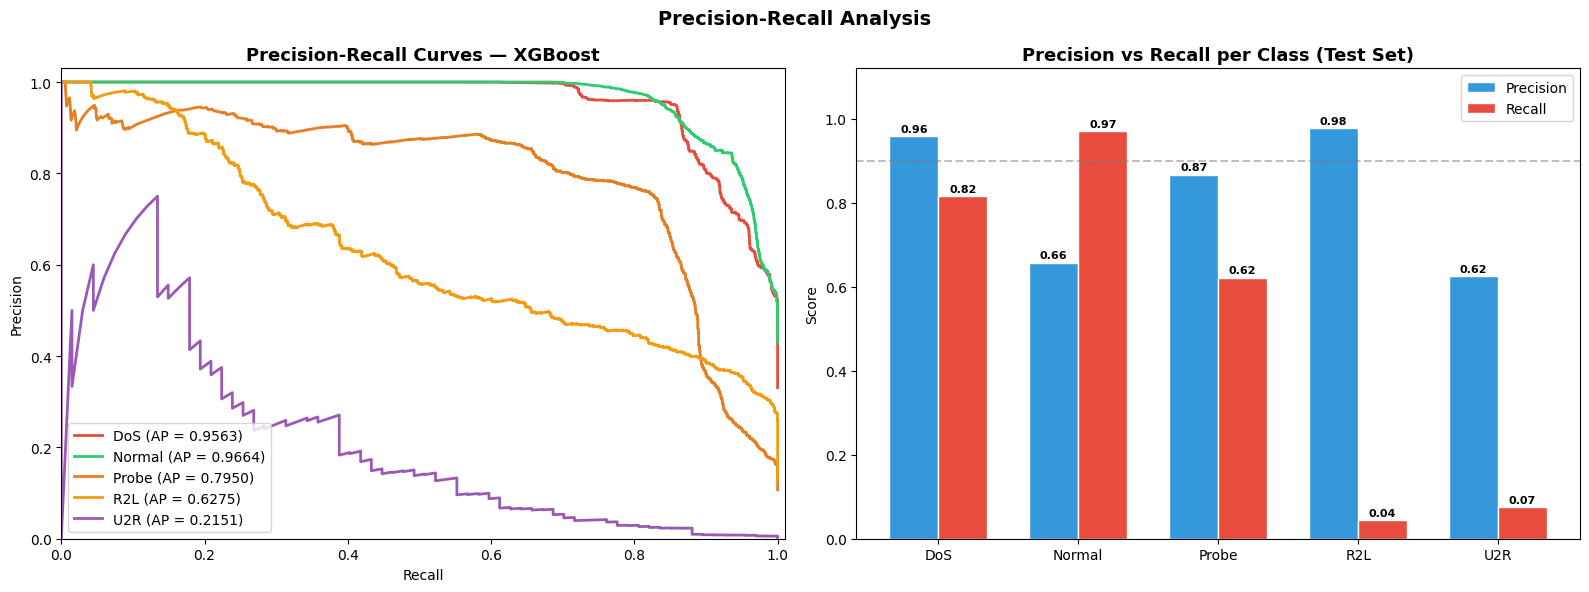

Average Precision per Class:
  DoS         AP = 0.9563
  Normal      AP = 0.9664
  Probe       AP = 0.7950
  R2L         AP = 0.6275
  U2R         AP = 0.2151


In [23]:
# ══════════════════════════════════════════════════════════
#  PRECISION-RECALL ANALYSIS
# ══════════════════════════════════════════════════════════
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ap_scores = {}
for i, cls in enumerate(CLASSES):
    precision, recall, _ = precision_recall_curve(
        y_test_bin_multi[:, i], y_prob[:, i])
    ap = average_precision_score(y_test_bin_multi[:, i], y_prob[:, i])
    ap_scores[cls] = ap
    axes[0].plot(recall, precision, linewidth=2,
                 color=CAT_COLORS.get(cls,'grey'),
                 label=f'{cls} (AP = {ap:.4f})')

axes[0].set_title(f'Precision-Recall Curves — {BEST}', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].legend(fontsize=10)
axes[0].set_xlim([0, 1.01])
axes[0].set_ylim([0, 1.03])

# Precision vs Recall per class grouped bar
x = np.arange(len(CLASSES))
width = 0.35
pre_vals = precision_score(y_test_enc, best_model.predict(X_test_top),
                           average=None, zero_division=0)
rec_vals = recall_score(y_test_enc, best_model.predict(X_test_top),
                        average=None, zero_division=0)

bars1 = axes[1].bar(x - width/2, pre_vals, width, label='Precision',
                    color='#3498db', edgecolor='white')
bars2 = axes[1].bar(x + width/2, rec_vals, width, label='Recall',
                    color='#e74c3c', edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(CLASSES)
axes[1].set_title('Precision vs Recall per Class (Test Set)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.12)
axes[1].legend(fontsize=10)
axes[1].axhline(0.9, color='grey', linestyle='--', alpha=0.5)
for bar in list(bars1)+list(bars2):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{bar.get_height():.2f}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Precision-Recall Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('precision_recall.png', dpi=130, bbox_inches='tight')
plt.show()

print("Average Precision per Class:")
for cls, ap in ap_scores.items():
    print(f"  {cls:<10}  AP = {ap:.4f}")

False Positive & False Negative Rates per Class:
-----------------------------------------------------------------
Class              TP       FP       FN       TN    FP Rate   FN Rate
-----------------------------------------------------------------
DoS             6,077      256    1,379   14,832    0.0170   0.1850!
Normal          9,426    4,912      285    7,921    0.3828!   0.0293
Probe           1,505      231      916   19,892    0.0115   0.3784!
R2L               126        3    2,763   19,652    0.0002   0.9564!
U2R                 5        3       62   22,474    0.0001   0.9254!


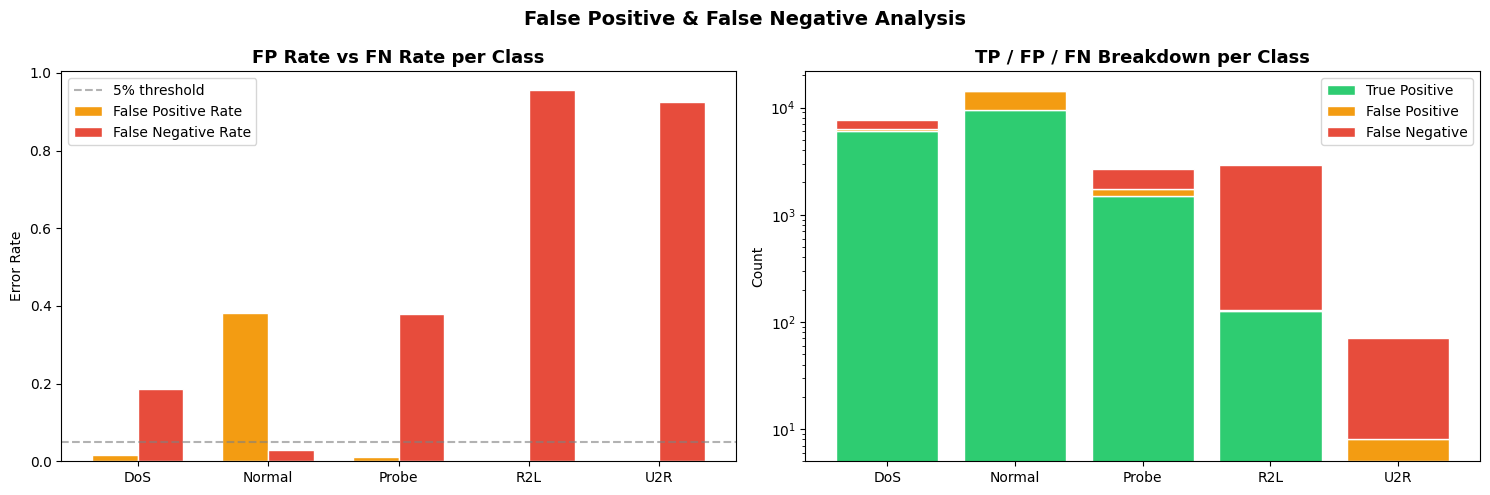

In [24]:
# FALSE POSITIVE & FALSE NEGATIVE ANALYSIS

test_preds_decoded = le_multi.inverse_transform(best_model.predict(X_test_top))

fp_fn = []
for cls in CLASSES:
    true_pos  = np.sum((np.array(y_test_m) == cls) & (test_preds_decoded == cls))
    false_pos = np.sum((np.array(y_test_m) != cls) & (test_preds_decoded == cls))
    false_neg = np.sum((np.array(y_test_m) == cls) & (test_preds_decoded != cls))
    true_neg  = np.sum((np.array(y_test_m) != cls) & (test_preds_decoded != cls))

    fp_rate = false_pos / (false_pos + true_neg + 1e-9)
    fn_rate = false_neg / (false_neg + true_pos + 1e-9)
    fp_fn.append({'Class': cls, 'TP': true_pos, 'FP': false_pos,
                  'FN': false_neg, 'TN': true_neg,
                  'FP_Rate': fp_rate, 'FN_Rate': fn_rate})

fp_fn_df = pd.DataFrame(fp_fn)

print("False Positive & False Negative Rates per Class:")
print("-" * 65)
print(f"{'Class':<12} {'TP':>8} {'FP':>8} {'FN':>8} {'TN':>8}  {'FP Rate':>9} {'FN Rate':>9}")
print("-" * 65)
for _, row in fp_fn_df.iterrows():
    fp_warn = '!' if row['FP_Rate'] > 0.05 else ''
    fn_warn = '!' if row['FN_Rate'] > 0.05 else ''
    print(f"{row['Class']:<12} {int(row['TP']):>8,} {int(row['FP']):>8,} "
          f"{int(row['FN']):>8,} {int(row['TN']):>8,}  "
          f"{row['FP_Rate']:>8.4f}{fp_warn} {row['FN_Rate']:>8.4f}{fn_warn}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# FP/FN rate comparison
x = np.arange(len(CLASSES))
w = 0.35
axes[0].bar(x-w/2, fp_fn_df['FP_Rate'], w, label='False Positive Rate',
            color='#f39c12', edgecolor='white')
axes[0].bar(x+w/2, fp_fn_df['FN_Rate'], w, label='False Negative Rate',
            color='#e74c3c', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(fp_fn_df['Class'])
axes[0].axhline(0.05, color='grey', linestyle='--', alpha=0.6, label='5% threshold')
axes[0].set_title('FP Rate vs FN Rate per Class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Error Rate')
axes[0].legend(fontsize=10)

# TP/FP/FN stacked bar
axes[1].bar(fp_fn_df['Class'], fp_fn_df['TP'],
            color='#2ecc71', label='True Positive', edgecolor='white')
axes[1].bar(fp_fn_df['Class'], fp_fn_df['FP'],
            bottom=fp_fn_df['TP'],
            color='#f39c12', label='False Positive', edgecolor='white')
axes[1].bar(fp_fn_df['Class'], fp_fn_df['FN'],
            bottom=fp_fn_df['TP']+fp_fn_df['FP'],
            color='#e74c3c', label='False Negative', edgecolor='white')
axes[1].set_title('TP / FP / FN Breakdown per Class', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_yscale('log')
axes[1].legend(fontsize=10)

plt.suptitle('False Positive & False Negative Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fp_fn_analysis.png', dpi=130, bbox_inches='tight')
plt.show()

---
# Model Explainability — Feature Impact per Attack Type



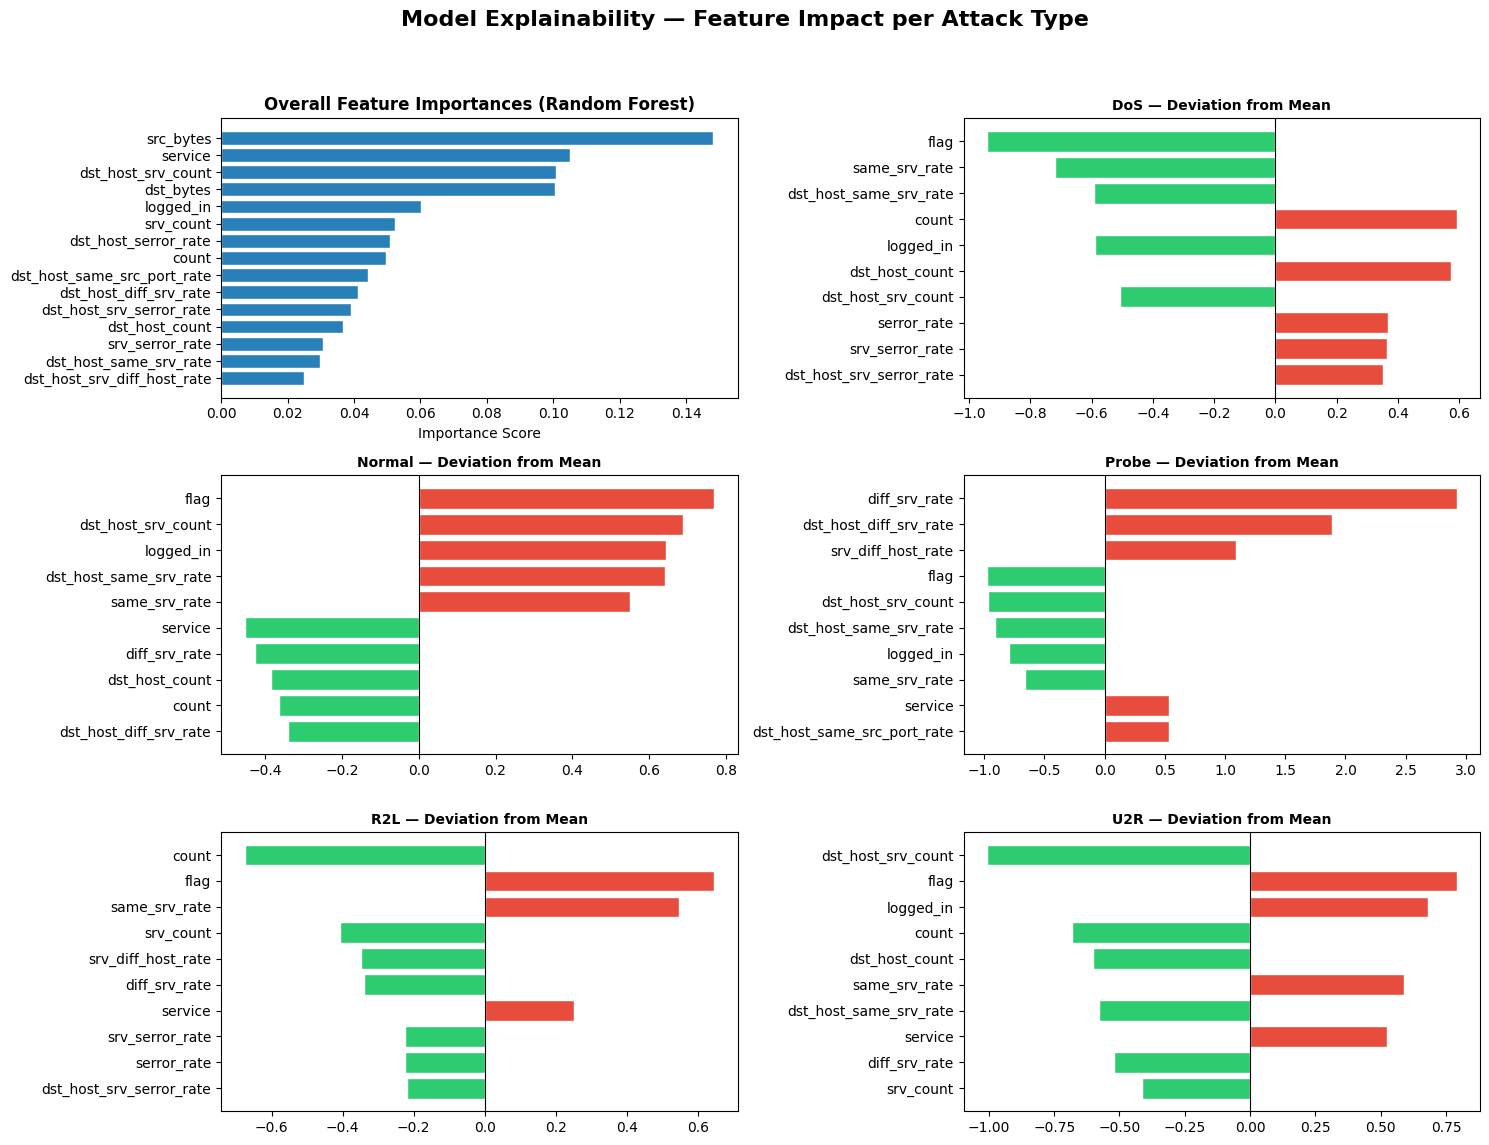

In [25]:
# ══════════════════════════════════════════════════════════
# MODEL EXPLAINABILITY
# ══════════════════════════════════════════════════════════
rf_model = trained_mdl.get('Random Forest')
fi_series = pd.Series(rf_model.feature_importances_, index=TOP_FEATS).sort_values(ascending=False)

# Setup: 1 row for overall importance, then 1 row for each class pair
n_classes = len(CLASSES)
cols = 2
rows = (n_classes // cols) + 1
fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten() # Makes it easy to loop through all subplots

# 1. Overall feature importance (First subplot)
axes[0].barh(fi_series.head(15).index[::-1], fi_series.head(15).values[::-1],
             color='#2980b9', edgecolor='white')
axes[0].set_title('Overall Feature Importances (Random Forest)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance Score')

# 2. Per-class feature deviation
overall_mean = np.mean(X_test_top, axis=0)
class_profiles = {cls: np.mean(X_test_top[np.array(y_test_m) == cls], axis=0) 
                  for cls in CLASSES if np.sum(np.array(y_test_m) == cls) > 5}

# Loop through classes and plot them starting from axes[1]
for i, cls in enumerate(CLASSES):
    ax = axes[i + 1] # Skip the first plot (Overall)
    if cls not in class_profiles:
        ax.set_visible(False)
        continue
        
    deviation = class_profiles[cls] - overall_mean
    feat_dev = pd.Series(deviation, index=TOP_FEATS)
    top_dev = feat_dev.abs().nlargest(10)
    colors_dev = ['#e74c3c' if feat_dev[f] > 0 else '#2ecc71' for f in top_dev.index]
    
    ax.barh(top_dev.index[::-1], [feat_dev[f] for f in top_dev.index[::-1]],
            color=colors_dev[::-1], edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{cls} — Deviation from Mean', fontsize=10, fontweight='bold')

# Hide any unused subplots
for j in range(len(CLASSES) + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Model Explainability — Feature Impact per Attack Type', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()